# colab_05 — Annotation, glia subset, and astrocyte residual-batch adjudication

Fifth notebook. Input is `integrated/scvi_integrated_full.h5ad` from colab_04 (694,922 cells /
134 donors / 46 Leiden clusters; full-gene raw counts in `.X`, scVI latent in `.obsm["X_scVI"]`).

**Three jobs:**
1. **Annotate** the 46 clusters (marker-score argmax, verified against canonical markers and the
   SEA-AD `orig_celltype` cross-check).
2. **Subset astrocytes + microglia** (ITS) from the full-gene object → the FM/FT substrate.
3. **Adjudicate the astrocyte within-niche residual-batch flag** from colab_04: cluster 22 is
   Li-pure (0.963); clusters 33/42/45 are SEA-AD-pure (~0.99). Technical batch, real-but-confounded
   biology, over-clustering, or a donor effect?

**The adjudication design is pre-registered** in `What we did.txt` (colab_05 preamble, written
before this notebook and before looking at new data). Calls baked in here:
- Stakes are **eval integrity**, not the FT substrate — CPT input is raw genes, not scVI space, and
  subsetting is robust either way. If the structure is batch/leakage it corrupts eval#2 (APOE-axis
  within astrocytes) and eval#1 (substate probe).
- **Six-lever battery, cheap-high-yield first:** (L5) donor decomposition → (L1) cross-study region
  overlap → (L4) QC-covariate + niche-mito diagnostic → (L3) DE program coherence → (L2) cross-study
  program replication → (L6) 2nd-scVI on the glia subset, **gated behind a batch verdict, run last**
  (reflexive re-integration would over-correct genuine reactive-astrocyte biology).
- Adjudicate cluster 22 (Li) and 33/42/45 (SEA-AD) **separately**; test 33/42/45 for over-clustering
  before testing for batch.
- Verdict is **weight-of-evidence, not proof** — study ≈ region ≈ sequencing-tech are near-confounded.

**Also here:** ID tiny cluster 0 (micro-adjacent, SEA-AD 0.70 — homeostatic microglia vs
perivascular macrophage?); **Audit C re-check** on the 134-donor set (SEA-AD lost 21
intermediate-ADNC donors in colab_04 5c → confirm ≥3 donors per test-stratum still holds).

**Runtime:** integration env (`requirements_integration.txt`, Py3.12, scvi-tools 1.4.3). The
2nd-scVI lever (6g, gated) needs the GPU; annotation / subset / levers L1–L5 are CPU-fine.

## 1 — Setup

### 1a — Mount Drive + clone/pull repo + install env

In [1]:
import os, subprocess, sys
from google.colab import drive

drive.mount("/content/drive")
DRIVE_ROOT = "/content/drive/MyDrive/ad-glia-fm-prep"
os.makedirs(DRIVE_ROOT, exist_ok=True)

REPO_URL  = "https://github.com/pavlemic/ad-glia-fm-prep.git"
REPO_PATH = "/content/ad-glia-fm-prep"

if not os.path.exists(REPO_PATH):
    subprocess.run(["git", "clone", REPO_URL, REPO_PATH], check=True)
else:
    subprocess.run(["git", "-C", REPO_PATH, "pull"], check=True)

if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)

assert sys.version_info[:2] == (3, 12), f"Expected Python 3.12, got {sys.version_info[:2]}"

# Pin numpy first so pip picks numpy-1.x-compatible wheels (same rationale as colab_01-04).
!pip install numpy==1.26.4
!pip install -r {REPO_PATH}/requirements_integration.txt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


> **Interpretation — setup (1a).**
>
> Integration env — the Py 3.12 / scvi-tools 1.4.3 line, deliberately separate from the Py 3.10 FM env used later for Geneformer/scGPT — resolves cleanly: after the `numpy==1.26.4`-first install every requirement reports *already satisfied* with no resolver conflicts. Drive mounted, repo pulled at commit `845c9fe` (the 4a t-test fix). Environment only, no findings.

## 2 — Environment capture

### 2a — pip freeze + env JSON

In [2]:
import json, platform, subprocess, sys
from datetime import date

NOTEBOOK_ID = "colab_05"
TODAY = date.today().isoformat()
VERSIONS_DIR = os.path.join(REPO_PATH, "outputs", "software_versions")
os.makedirs(VERSIONS_DIR, exist_ok=True)

FREEZE_PATH = os.path.join(VERSIONS_DIR, f"{NOTEBOOK_ID}_{TODAY}_pip_freeze.txt")
!pip freeze > {FREEZE_PATH}

def _run(cmd):
    try:
        return subprocess.run(cmd, capture_output=True, text=True, check=True).stdout.strip()
    except (FileNotFoundError, subprocess.CalledProcessError):
        return None

def _ver(mod):
    try:
        return __import__(mod).__version__
    except Exception:
        return None

env_snapshot = {
    "notebook_id":    NOTEBOOK_ID,
    "date":           TODAY,
    "python_version": sys.version,
    "platform":       platform.platform(),
    "os_release":     platform.release(),
    "gpu":            _run(["nvidia-smi", "-L"]),
    "nvidia_driver":  _run(["nvidia-smi", "--query-gpu=driver_version", "--format=csv,noheader"]),
    "git_commit":     _run(["git", "-C", REPO_PATH, "rev-parse", "HEAD"]),
    "scvi_tools_version": _ver("scvi"),
    "scanpy_version":     _ver("scanpy"),
    "anndata_version":    _ver("anndata"),
    "jax_version":        _ver("jax"),
    "scib_metrics_version": _ver("scib_metrics"),
}
try:
    import torch
    env_snapshot["torch_version"]      = torch.__version__
    env_snapshot["torch_cuda_version"] = torch.version.cuda
    env_snapshot["cuda_available"]     = bool(torch.cuda.is_available())
    env_snapshot["cudnn_version"]      = torch.backends.cudnn.version() if torch.cuda.is_available() else None
except ImportError:
    env_snapshot["torch_version"]  = None
    env_snapshot["cuda_available"] = None
    env_snapshot["cudnn_version"]  = None

ENV_JSON_PATH = os.path.join(VERSIONS_DIR, f"{NOTEBOOK_ID}_{TODAY}_env.json")
with open(ENV_JSON_PATH, "w") as f:
    json.dump(env_snapshot, f, indent=2)
print(json.dumps(env_snapshot, indent=2))

/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.7.1, so it will not be used.
  warnings.warn(


{
  "notebook_id": "colab_05",
  "date": "2026-06-14",
  "python_version": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "os_release": "6.6.122+",
  "gpu": "GPU 0: NVIDIA A100-SXM4-80GB (UUID: GPU-59fc797d-fc23-7b63-70cb-efc4674cd385)",
  "nvidia_driver": "580.82.07",
  "git_commit": "845c9fe4bd483815b72a6157d80fc9eecdab75dc",
  "scvi_tools_version": "1.4.3",
  "scanpy_version": "1.10.4",
  "anndata_version": "0.11.4",
  "jax_version": "0.7.1",
  "scib_metrics_version": "0.5.5",
  "torch_version": "2.11.0+cu128",
  "torch_cuda_version": "12.8",
  "cuda_available": true,
  "cudnn_version": 91900
}


> **Interpretation — environment snapshot (2a).**
>
> Exact provenance for the Methods record: scvi-tools 1.4.3, scanpy 1.10.4, anndata 0.11.4, scib-metrics 0.5.5, torch 2.11.0+cu128, CUDA 12.8, git `845c9fe`, on an **A100-SXM4-80GB** (driver 580.82.07). One benign warning — JAX plugin 0.7.2 vs jaxlib 0.7.1 mismatch — JAX simply falls back and scvi-tools trains on torch, so it has no effect. Same 80 GB card and env line as colab_04, so the integrated object reloads under identical conditions.

## 3 — Load the integrated object

### 3a — Load `scvi_integrated_full.h5ad`, sanity-check latent + raw counts

In [3]:
import gc
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt

try:
    import psutil
    def _ram(tag):
        m = psutil.virtual_memory()
        print(f"[RAM] {tag:24s}: {m.used/1e9:5.1f} / {m.total/1e9:.1f} GB ({m.percent:.0f}%)")
except ImportError:
    def _ram(tag): pass

INTEGRATED_PATH = os.path.join(DRIVE_ROOT, "integrated", "scvi_integrated_full.h5ad")
if not os.path.exists(INTEGRATED_PATH):
    raise FileNotFoundError(f"missing integrated object {INTEGRATED_PATH} (colab_04 7a output)")

adata = sc.read_h5ad(INTEGRATED_PATH)
print("loaded:", adata.shape)
_ram("loaded integrated")

# structural sanity checks (fail loud)
assert "X_scVI" in adata.obsm, "missing obsm['X_scVI'] - colab_04 latent not present"
for col in ["study_id", "leiden_scvi", "donor_id", "region", "diagnosis",
            "apoe_carrier", "apoe_genotype"]:
    assert col in adata.obs.columns, f"missing obs['{col}']"

# raw-counts guard (same random-sample integer check as colab_04 3a; head-slice hides sorted tails)
_rng = np.random.default_rng(0)
_idx = _rng.choice(adata.n_obs, size=min(2000, adata.n_obs), replace=False)
Xs = adata.X[_idx]
_data = Xs.data if sp.issparse(Xs) else np.asarray(Xs).ravel()
frac_int = float(np.mean(np.mod(_data, 1) == 0)) if _data.size else 1.0
assert frac_int >= 0.99, f".X not raw counts (int frac {frac_int:.3f})"

adata.obs["leiden_scvi"] = adata.obs["leiden_scvi"].astype(str)
print(f"cells={adata.n_obs}  genes={adata.n_vars}  donors={adata.obs['donor_id'].nunique()}")
print(f"leiden clusters: {adata.obs['leiden_scvi'].nunique()}  (expected 46)")
print("study fractions:\n", adata.obs["study_id"].value_counts(normalize=True).round(3))
print("raw-counts int-frac:", round(frac_int, 3))

loaded: (694922, 26514)
[RAM] loaded integrated       :  29.9 / 179.4 GB (18%)
cells=694922  genes=26514  donors=145
leiden clusters: 46  (expected 46)
study fractions:
 study_id
Li2025       0.550
SEA-AD       0.294
Haney2024    0.157
Name: proportion, dtype: float64
raw-counts int-frac: 1.0


> **Interpretation — load + latent/raw-counts guard (3a).**
>
> The post-5c clean object reloads exactly as colab_04 saved it: **694,922 x 26,514**, **46 Leiden clusters** (matches expected), 145 donors, study mix Li 0.550 / SEA-AD 0.294 / Haney 0.157. Two guards pass: **`raw-counts int-frac = 1.0`** confirms `.X` is still integer counts (required before the lognorm layer is built in 4a and for any NB-based scoring), and `X_scVI` + `leiden_scvi` survive the round-trip. RAM 18%. Ready to annotate.

## 4 — Annotate the 46 clusters

Integration (colab_04) sorted the 694,922 nuclei into **46 Leiden clusters** using only the scVI latent space — i.e. purely by transcriptional similarity, with no biological labels attached. At this point a cluster is just "a group of nuclei with similar expression": it has a number, not an identity. **Annotation** is the step that gives each numbered cluster a biological cell type (astrocyte, microglia, neuron, oligodendrocyte, …) by asking which known marker genes it expresses. It is the prerequisite for everything downstream — we can only subset "astrocytes + microglia" (the niche this project studies) once every cluster has a name.

### 4a — Per-cluster marker DE + canonical-marker dotplot

Two complementary reads of cluster identity:

1. **Data-driven — `rank_genes_groups`.** For each cluster, find the genes most over-expressed relative to all other clusters, with no prior assumption. This lets the data speak: if a cluster's top genes happen to be myelin genes, it is an oligodendrocyte. (Run here with a t-test rather than the Wilcoxon test — the interpretation explains why, and why we read it only loosely.)
2. **Knowledge-driven — the canonical-marker dotplot.** Take a curated list of genes that are textbook markers of each brain cell type and ask which clusters express them.

**How to read the dotplot.** Rows are the 46 clusters; columns are marker genes, grouped left-to-right by the cell type they mark (an astrocyte block, then a microglia block, and so on). Each dot carries two numbers: its **color** is the average expression of that gene in that cluster (scaled 0–1 within each column, so it is *relative across clusters*, not an absolute level), and its **size** is the fraction of cells in the cluster that express the gene at all. A cluster's identity is simply the marker block in which its row shows large, dark dots.

/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:429: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:434: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result

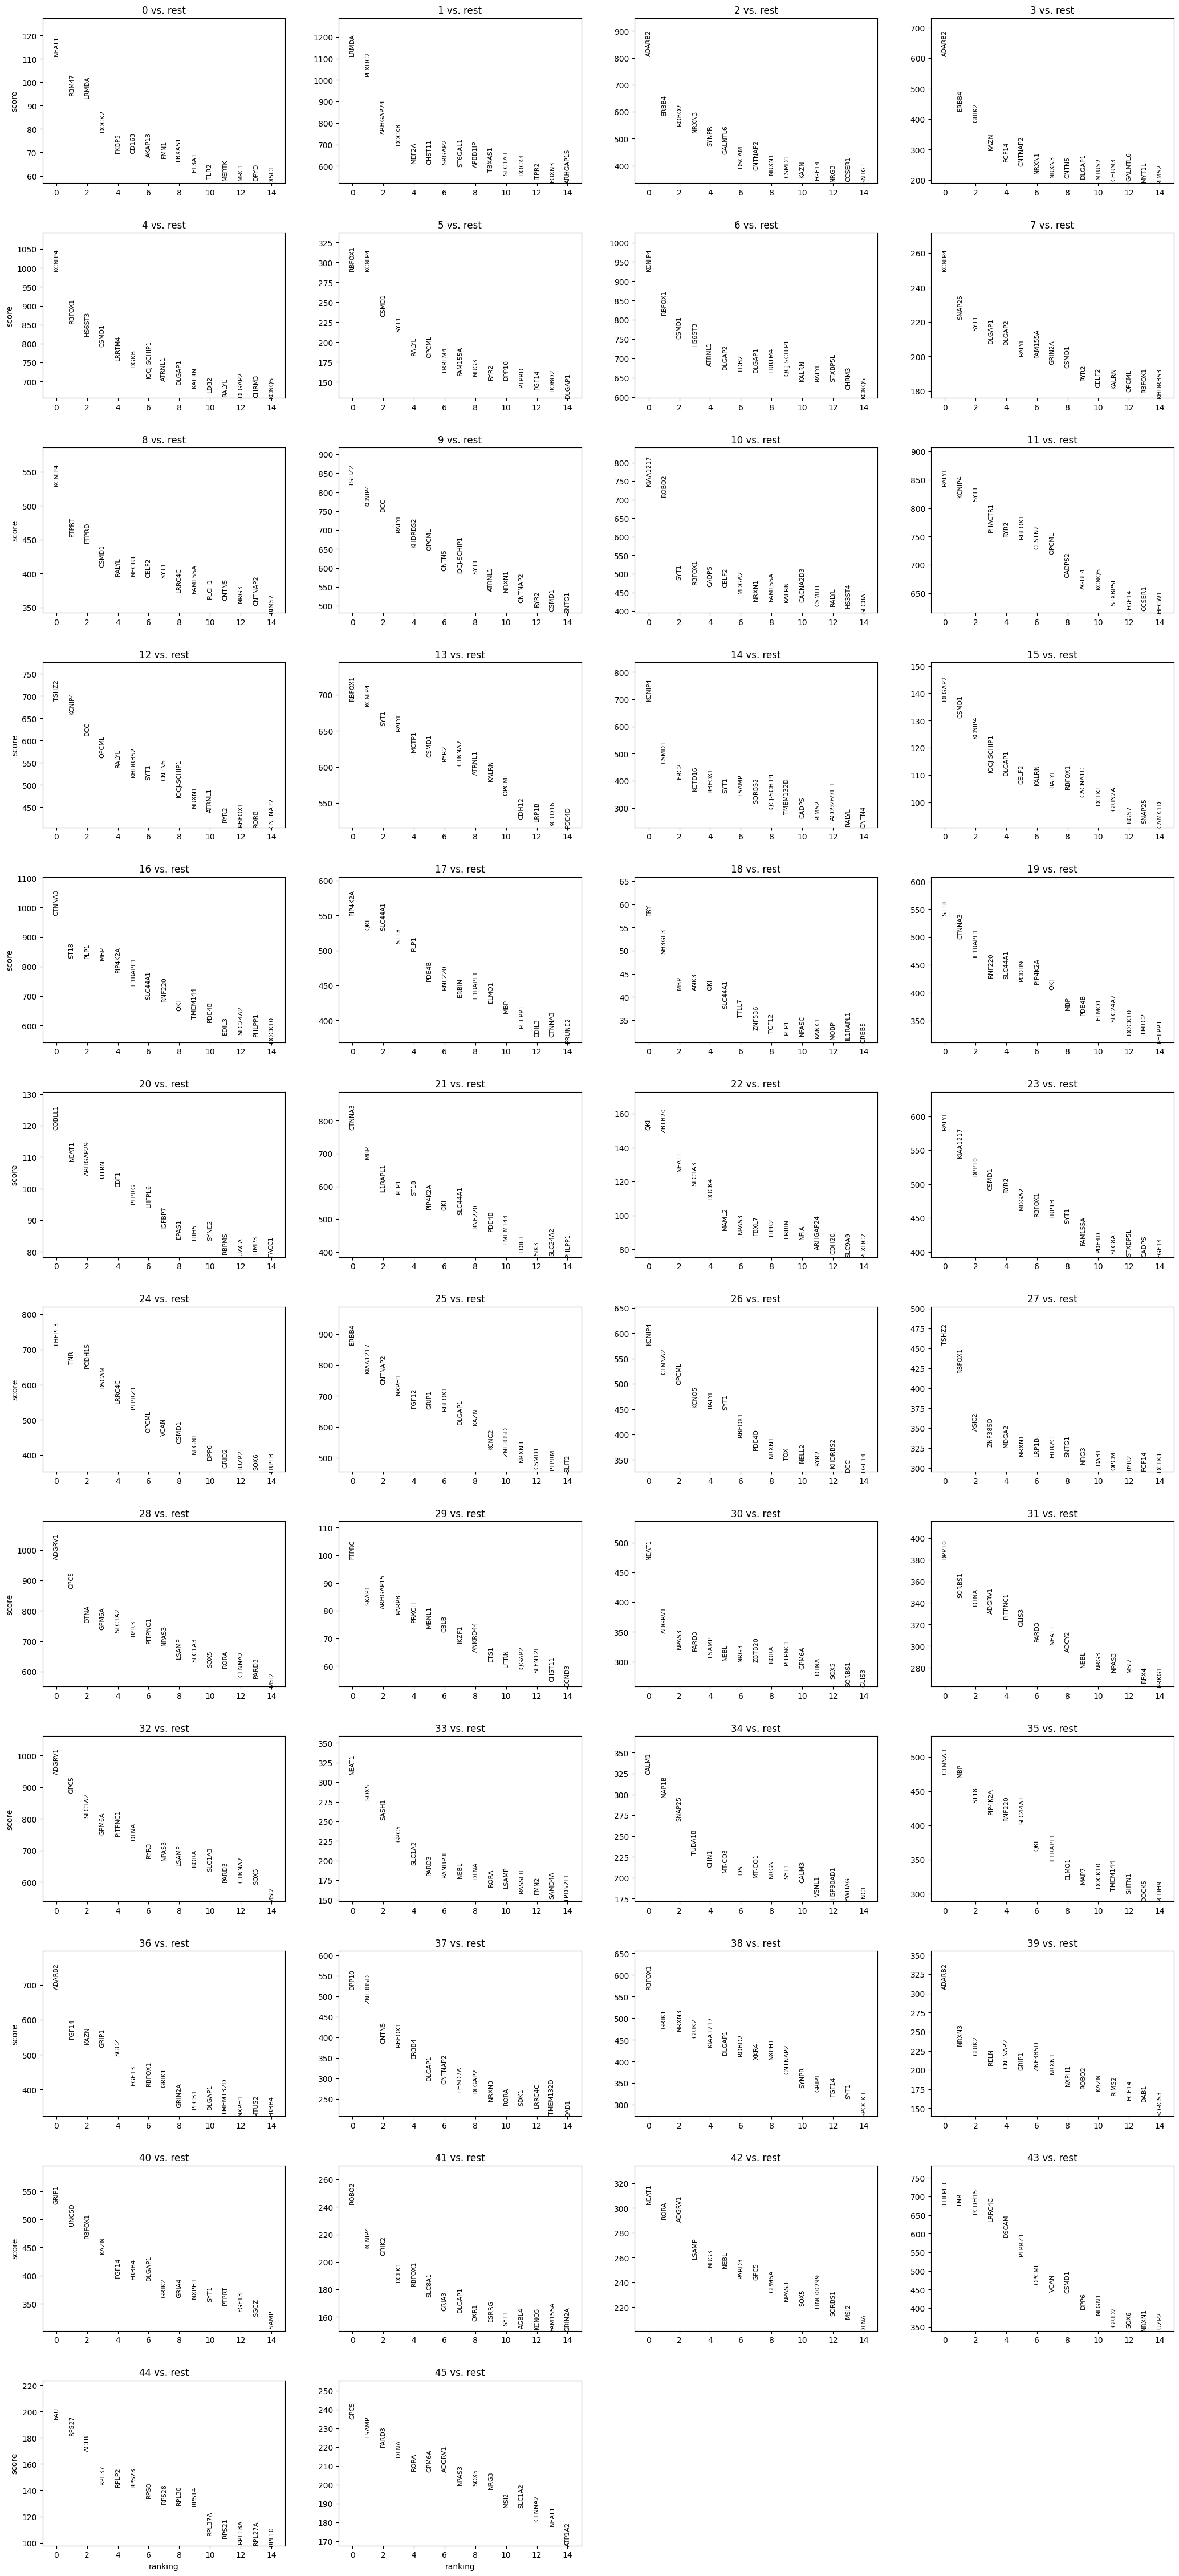

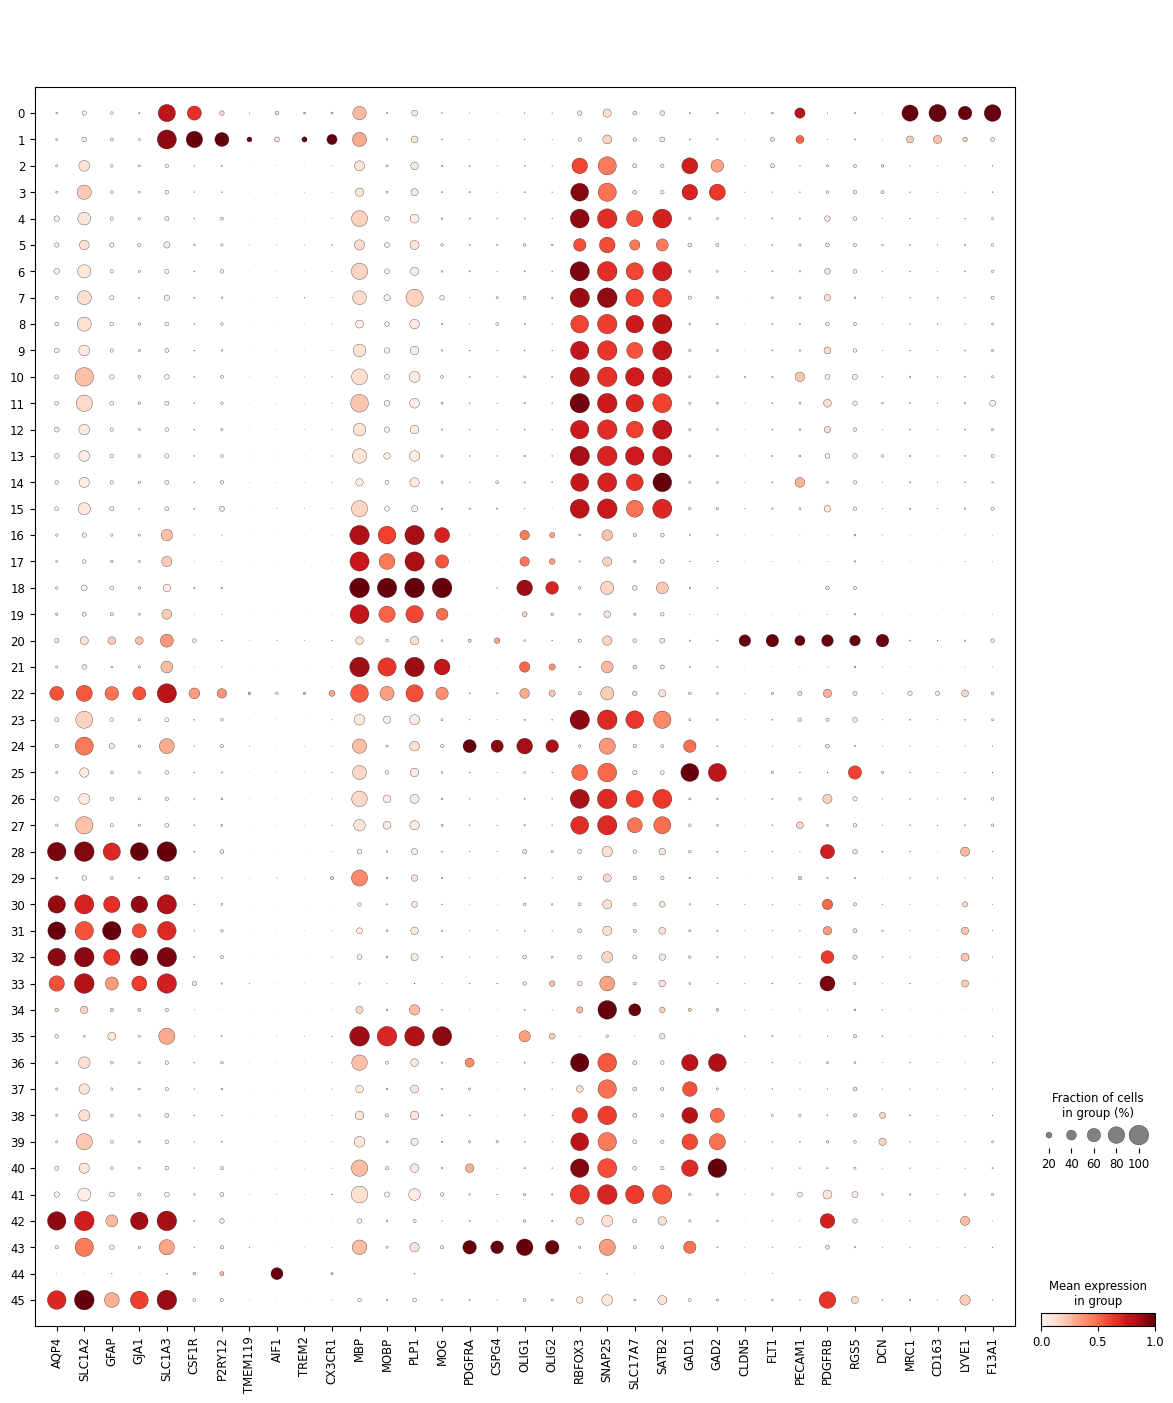

In [4]:
# log-normalized layer for marker visualization + scoring; .X stays raw counts throughout
adata.layers["lognorm"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4, layer="lognorm")
adata.uns.pop("log1p", None)        # stale guard from colab_04 would make layer-level log1p silently skip
sc.pp.log1p(adata, layer="lognorm")

# canonical markers per major brain cell type (only those present in the intersection gene set)
MARKERS = {
    "astrocyte":        ["AQP4", "SLC1A2", "GFAP", "GJA1", "SLC1A3"],
    "microglia":        ["CSF1R", "P2RY12", "TMEM119", "AIF1", "TREM2", "CX3CR1"],
    "oligodendrocyte":  ["MBP", "MOBP", "PLP1", "MOG"],
    "OPC":              ["PDGFRA", "CSPG4", "OLIG1", "OLIG2"],
    "neuron_exc":       ["RBFOX3", "SNAP25", "SLC17A7", "SATB2"],
    "neuron_inh":       ["GAD1", "GAD2"],
    "endothelial":      ["CLDN5", "FLT1", "PECAM1"],
    "mural":            ["PDGFRB", "RGS5", "DCN"],
    "perivascular_mac": ["MRC1", "CD163", "LYVE1", "F13A1"],
}
present = {ct: [g for g in gs if g in adata.var_names] for ct, gs in MARKERS.items()}
for ct, gs in present.items():
    missing = set(MARKERS[ct]) - set(gs)
    if missing:
        print(f"[markers] {ct}: absent from gene set -> {sorted(missing)}")

# per-cluster top DE genes for eyeballing identity
# t-test used (not Wilcoxon): this is the full 694k-cell object; Wilcoxon is O(n^2) per gene
# and timed out at >3h on A100. t-test is fast and sufficient for visual cluster annotation.
sc.tl.rank_genes_groups(adata, groupby="leiden_scvi", layer="lognorm",
                        method="t-test", n_genes=15, use_raw=False)
sc.pl.rank_genes_groups(adata, n_genes=15, sharey=False, show=True)

# dotplot of canonical markers across all clusters
flat = [g for gs in present.values() for g in gs]
sc.pl.dotplot(adata, var_names=flat, groupby="leiden_scvi", layer="lognorm",
              standard_scale="var", show=True)

> **Interpretation — per-cluster marker DE + dotplot (4a).**
>
> **The statistic, first.** `rank_genes_groups` is run with a **t-test** (Wilcoxon timed out >3h on the full 694k-cell object), so 4a is a **fast visual first pass, not the rigorous DE** — the gene *ordering* in the panels is t-test-driven and must not be over-read. The defensible statistics live downstream: **4b**'s per-cluster score table for annotation, and **6e/6f** (Wilcoxon) for the astrocyte niche.
>
> **Reading the dotplot block by block** (left to right; each block is one cell type's canonical markers, and the clusters whose rows light that block are that cell type — every assignment below is confirmed numerically by 4b's score table, not eyeballed):
>
> - **Astrocytes** — *AQP4* (the water channel packed into the astrocyte "endfeet" that wrap blood vessels), *SLC1A2 / SLC1A3* (the EAAT2 / EAAT1 transporters astrocytes use to vacuum glutamate out of synapses), *GFAP* (the intermediate-filament protein that defines astrocytes and rises sharply in reactive ones), *GJA1* (connexin-43, the gap junctions that electrically couple astrocytes). Rows that light this block = clusters {22, 28, 30, 31, 32, 33, 42, 45}.
> - **Microglia** — *CSF1R* (the survival receptor of the myeloid lineage), *P2RY12 / TMEM119 / CX3CR1* (the "homeostatic" sensome of resting microglia, switched off on activation), *AIF1* (IBA1, pan-microglial), and *TREM2* (the Alzheimer's-risk gene that marks disease-associated microglia — the single gene we force-injected in colab_04 precisely so it would be visible here). Rows that light this block = cluster 1 (microglia score 0.63 in 4b).
> - **Oligodendrocytes** — *MBP, MOBP, PLP1, MOG*: the structural proteins of myelin itself, so a cluster expressing them is a mature, myelin-making oligodendrocyte. Clusters {16, 17, 18, 19, 21, 35}.
> - **OPCs** (oligodendrocyte precursor cells) — *PDGFRA, CSPG4* (NG2), *OLIG1 / OLIG2* (lineage transcription factors): the still-dividing progenitors that have not yet started making myelin.
> - **Neurons**, split two ways — **excitatory**: *RBFOX3* (NeuN) and *SNAP25* are pan-neuronal, *SLC17A7* (VGLUT1) is the vesicular transporter that loads the excitatory transmitter glutamate, *SATB2* is a cortical excitatory-neuron transcription factor; **inhibitory**: *GAD1 / GAD2*, the two enzymes that synthesize the inhibitory transmitter GABA. Neurons fill the large lower blocks — clusters 2 / 3 score inhibitory and 4–15 excitatory in 4b.
> - **Vascular and border cells** (the small right-hand blocks) — **endothelial**: *CLDN5* (claudin-5, the tight-junction protein that seals the blood–brain barrier), *FLT1, PECAM1* (CD31); **mural / pericytes**: *PDGFRB, RGS5*, the contractile cells wrapping capillaries; **perivascular macrophages**: *MRC1* (CD206), *CD163, LYVE1, F13A1* — immune cells residing in the perivascular space, a distinct population from the parenchymal microglia above.
>
> **What 4a licenses.** Every cluster shows one clearly dominant block, so each resolves to a recognizable lineage and the partition is annotatable. This visual read is corroborated quantitatively by **4b's per-cluster x 9-signature score table** — every cluster carries a clean positive argmax (e.g. cl0 perivascular_mac 2.14, cl1 microglia, cl2/3 inhibitory, cl4–15 excitatory neurons). 4a is simply the human-readable view of the same marker logic 4b formalizes into a number.
>
> **Two low-margin exceptions, flagged rather than resolved here.** **cl22** (astrocyte 1.09 vs oligodendrocyte 0.99, margin 0.093): its row lights *both* the astrocyte block and the myelin block at once — the classic signature of ambient RNA, where free-floating myelin transcripts from lysed oligodendrocytes contaminate astrocyte nuclei. Carried to the 6-lever battery, where **6e** confirms its top up-genes are oligodendrocyte/myelin (ELMO1, ST18, MOBP, MBP, CTNNA3, PLP1) — contamination, not a real astrocyte state. **cl44** (microglia 0.32, every absolute score low): no block lights strongly, so its identity is weak; flagged for inspection inside the microglia subset. **cl0** lights the perivascular-macrophage block (not the microglia block) and is resolved decisively in **4c**.

### 4b — Marker-score argmax assignment + cross-check

4a was a visual read; 4b turns the same canonical markers (the panels defined in 4a) into a **number per cell**, making the cluster-to-cell-type assignment objective and auditable.

**The score.** `score_genes` takes one cell type's marker list and, for each cell, computes the mean expression of those markers minus the mean of a random set of control genes matched for expression level. A **positive score** means the cell expresses that signature above background; near 0 or negative means it does not. We compute all nine signatures, average them within each Leiden cluster, and assign the cluster to its highest-scoring type (the **argmax**).

**The margin = confidence.** For each cluster we also report `top score − second-best score`. A large margin (an oligodendrocyte cluster scoring +2 on oligo and near 0 elsewhere) is an unambiguous call; a small margin means two cell types compete and the label is shaky. Clusters with margin < 0.05 are failed-loud for manual review.

**Two independent cross-checks.** (1) against the **colab_04 territory map** — the 14 anchor clusters it had already called from UMAP marker overlays must come back with the same label here; (2) against **SEA-AD's own published labels** (`orig_celltype`) — SEA-AD shipped expert annotations, so our labels should line up with theirs on SEA-AD cells. Li and Haney shipped no labels, so they appear as `NA` and are only checkable internally.

In [6]:
# score each cell per cell-type signature (on lognorm via an X-swap), assign each Leiden cluster
# to the highest mean-scoring type, and fail loud on low-margin (ambiguous) clusters.
score_cols = []
X_raw = adata.X
adata.X = adata.layers["lognorm"]          # score on log-norm
try:
    for ct, gs in present.items():
        if gs:
            sc.tl.score_genes(adata, gene_list=gs, score_name=f"score_{ct}", use_raw=False)
            score_cols.append(f"score_{ct}")
finally:
    adata.X = X_raw                         # ALWAYS restore raw counts

S = adata.obs.groupby("leiden_scvi", observed=True)[score_cols].mean()
S.columns = [c.replace("score_", "") for c in S.columns]
top = S.idxmax(axis=1)
srt = np.sort(S.values, axis=1)
margin = pd.Series(srt[:, -1] - srt[:, -2], index=S.index)   # top minus 2nd-best
assign = pd.DataFrame({"cell_type": top, "margin": margin.round(3)})
with pd.option_context("display.max_rows", None, "display.width", 160):
    print("per-cluster mean marker scores:"); print(S.round(2))
    print("\nassignment (sorted by margin):"); print(assign.sort_values("margin"))
AMBIG = assign.index[assign["margin"] < 0.05].tolist()
if AMBIG:
    print(f"\n[AMBIGUOUS - manual review] score margin <0.05 at clusters: {AMBIG}")

# anchor clusters from the colab_04 territory map - assert score-argmax agrees, flag if not
ANCHORS = {
    "microglia":       ["1"],
    "astrocyte":       ["22", "28", "30", "31", "33", "42", "45"],
    "oligodendrocyte": ["16", "17", "18", "19", "21", "35"],
}
print("\nanchor check vs colab_04 territory map:")
for ct, cls in ANCHORS.items():
    for cl in cls:
        got = assign.loc[cl, "cell_type"] if cl in assign.index else "MISSING"
        flag = "" if got == ct else "   <-- DISAGREES, review markers in 4a"
        print(f"  cl{cl:>2}: colab_04={ct:15s} score-argmax={got}{flag}")

# map cluster -> cell_type onto cells (cluster 0 finalized in 4c; tentative here)
adata.obs["cell_type"] = adata.obs["leiden_scvi"].map(assign["cell_type"]).astype(str)
unmapped = adata.obs["cell_type"].isin(["nan", "None"]).sum()
assert unmapped == 0, f"{unmapped} cells unmapped - every cluster must receive a label"

# cross-check vs SEA-AD inherited labels (orig_celltype), where present
if "orig_celltype" in adata.obs.columns:
    print("\ncell_type x orig_celltype (SEA-AD cross-check):")
    _oc = adata.obs["orig_celltype"].astype("object").fillna("NA")  # Categorical-safe
    xc = pd.crosstab(adata.obs["cell_type"], _oc)
    with pd.option_context("display.max_columns", None, "display.width", 200):
        print(xc)
print("\ncell_type x study:")
print(pd.crosstab(adata.obs["cell_type"], adata.obs["study_id"]))

per-cluster mean marker scores:
             astrocyte  microglia  oligodendrocyte   OPC  neuron_exc  neuron_inh  endothelial  mural  perivascular_mac
leiden_scvi                                                                                                           
0                 0.20       0.17            -0.17 -0.08       -0.28       -0.15         0.20  -0.08              2.14
1                 0.31       0.63            -0.07 -0.08       -0.23       -0.13         0.16  -0.07              0.29
2                -0.47      -0.08            -0.47 -0.09        0.02        0.65         0.00  -0.02             -0.05
3                -0.37      -0.07            -0.50 -0.08        0.20        0.93        -0.03  -0.00             -0.05
4                -0.57      -0.08            -0.54 -0.10        0.78       -0.19        -0.03  -0.05             -0.05
5                -0.27      -0.05            -0.24 -0.05        0.60       -0.07        -0.01  -0.02             -0.03
6               

> **Interpretation — score-argmax annotation + cross-check (4b).**
>
> **Reading the score table** (rows = the 46 clusters, columns = the nine cell-type signatures, each value = that cluster's mean `score_genes` value for the signature; the assigned label is the row's argmax). The calls are mostly emphatic: oligodendrocyte clusters score +1.6 to +2.9 on oligo and near 0 elsewhere (cl18 +2.85), astrocyte clusters +1.1 to +2.0 on astro (cl28 +2.01, cl32 +1.95), cl0 +2.14 on perivascular-macrophage, cl20 lights endothelial +1.29 *and* mural +1.00 (a small blood-vessel cluster mixing the two vessel-wall cell types), and the large neuronal field splits cleanly into excitatory (+0.6 to +1.0 on neuron_exc) and inhibitory (cl25/36/40 at +1.2 to +1.3 on neuron_inh). Every cluster has a clearly positive argmax — none is unlabelable.
>
> **The margin column says how trustworthy each call is** (top minus second-best score). Sorted ascending, the two weakest are **cl22 (0.093: astrocyte 1.09 vs oligodendrocyte 0.99 — a near-tie)** and **cl29 (0.096: a weak oligodendrocyte at +0.08)**; the strongest are the oligodendrocyte and astrocyte clusters (margins 1.3–2.5). No cluster falls below the 0.05 fail-loud threshold, so nothing is formally ambiguous — but the thin margins are the early warning. cl22's near-tie is the **first independent sign of its ambient-myelin problem**, surfacing here at the annotation step, before the 6-lever battery confirms it. **cl44** is labelled microglia but on a weak margin (0.319) with a low absolute score (microglia 0.32 vs cl1's 0.63) → flagged for inspection inside the microglia subset before it can ride into the niche. (cl0's label is tentative here and is finalized in 4c.)
>
> **Anchor cross-check: 14/14 agree.** Every cluster colab_04 had called from UMAP marker overlays (microglia cl1; astrocytes cl22/28/30/31/33/42/45; oligodendrocytes cl16/17/18/19/21/35) returns the identical label from the independent score-argmax — two different methods converging. The one *addition*: **cl32 is promoted to astrocyte** (astro score **1.95**, margin **1.788**, well-mixed across studies), a legitimate astrocyte simply absent from colab_04's anchor list → final astrocyte set = **8 clusters** {22,28,30,31,32,33,42,45}.
>
> **SEA-AD label cross-check** (`cell_type` rows × SEA-AD's published `orig_celltype` columns; entries are cell counts). Our coarse labels map onto SEA-AD's fine subclasses exactly as they should: astrocyte → Astrocyte (51,027), oligodendrocyte → Oligodendrocyte (11,381), OPC → OPC (3,723); our **neuron_inh** column collects every GABAergic SEA-AD subclass (Pvalb 8,279 / Vip 10,842 / Sst 4,755 / Lamp5 / Sncg / Chandelier / Pax6) while **neuron_exc** collects the glutamatergic IT/ET/CT types (L2/3 IT 31,189, L4 IT 17,556, …) — strong external validation. The informative split is myeloid: SEA-AD lumps everything into one **`Microglia-PVM`** label, which our pass *resolves* into homeostatic microglia (27,561 SEA-AD cells) vs perivascular macrophage (937 SEA-AD cells of cl0 — cl0 totals 1,344 across all three studies, see 4c) — our annotation is **finer** than the inherited one. Off-diagonal leakage is negligible (e.g. 661 PVM-labelled cells bleeding into oligodendrocyte). The large **`NA` column is Li + Haney**, which ship no labels — so this cross-check validates against SEA-AD only.
>
> **`cell_type` × study** confirms the substrate and foreshadows cl22: astrocytes total **94,271** (Li 30,121 / SEA 51,084 / Haney 13,066) and microglia **55,104** are the niche, but note **oligodendrocytes are overwhelmingly Li (136,763 of 191,459)** — a large pool of myelin transcripts in the Li samples, exactly the ambient source the Li-pure cl22 will turn out to be picking up.

### 4c — Identify tiny cluster 0 (homeostatic microglia vs perivascular macrophage)

4b's argmax already labelled the tiny cluster 0 a perivascular macrophage — but on a small (ca. 1,300-cell), microglia-adjacent, SEA-AD-heavy cluster that call is worth a dedicated check before it changes what enters the niche. The distinction is biologically real and consequential: **homeostatic microglia** are the brain's resident *parenchymal* immune cells (markers P2RY12 / TMEM119 / CX3CR1); **perivascular macrophages (PVM)** are a *different* myeloid population living in the perivascular space around blood vessels (markers MRC1 / CD163 / LYVE1 / F13A1). Both are myeloid, so a coarse signature score can blur them — hence a focused two-cluster dotplot (cl0 vs the bona-fide microglia cl1) on just these two marker panels (read as in 4a). The stakes: PVM are **not** part of the astrocyte+microglia niche, so if cl0 is PVM it must drop at 5a rather than contaminate the microglia substate analysis (eval#1).

cluster sizes: {'1': 54805, '0': 1344}


/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


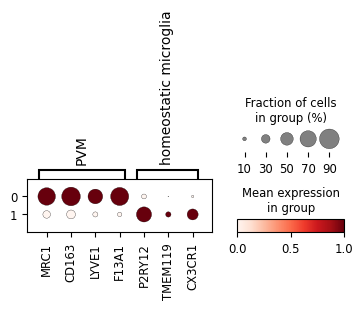

study_id     Li2025  SEA-AD  Haney2024
leiden_scvi                           
0             0.204   0.697      0.099
1             0.368   0.503      0.129


In [7]:
# cluster 0 is microglia-adjacent and SEA-AD-heavy (~0.70). Homeostatic microglia express
# P2RY12/TMEM119/CX3CR1; perivascular macrophages (PVM) express MRC1/CD163/LYVE1/F13A1.
pvm   = [g for g in ["MRC1", "CD163", "LYVE1", "F13A1"] if g in adata.var_names]
homeo = [g for g in ["P2RY12", "TMEM119", "CX3CR1"]    if g in adata.var_names]
probe = ["0", "1"]
sub = adata[adata.obs["leiden_scvi"].isin(probe)]
print("cluster sizes:", sub.obs["leiden_scvi"].value_counts().to_dict())
sc.pl.dotplot(sub, var_names={"PVM": pvm, "homeostatic microglia": homeo},
              groupby="leiden_scvi", layer="lognorm", standard_scale="var", show=True)
print(pd.crosstab(sub.obs["leiden_scvi"], sub.obs["study_id"], normalize="index").round(3))
# VERDICT recorded in _OUTPUT after reading the dotplot. If PVM, relabel cluster 0:
#   adata.obs.loc[adata.obs["leiden_scvi"]=="0", "cell_type"] = "perivascular_mac"
# (PVM are NOT part of the microglia niche -> would drop from the glia subset in 5a).

> **Interpretation — cluster 0: PVM vs microglia (4c).**
>
> **Sizes:** cl0 = 1,344 cells, cl1 = 54,805 — cl1 is the main microglia body, cl0 the small candidate being adjudicated.
>
> **The dotplot is unambiguous and mirror-symmetric** (rows = the two clusters; left panel = PVM markers, right panel = homeostatic-microglia markers; dot color = relative mean expression, size = fraction of cells expressing, as in 4a). **cl0:** MRC1, CD163, LYVE1, F13A1 are all large and dark (high fraction, top relative expression), while P2RY12 / TMEM119 / CX3CR1 are tiny near-empty circles → **perivascular macrophage**. **cl1** is the exact mirror — the PVM markers are faint and the homeostatic panel is large and dark (P2RY12 strongest, then TMEM119 / CX3CR1) → **homeostatic microglia**. The two myeloid populations separate cleanly, not as a gradient.
>
> **Study composition** (cl0: SEA-AD 0.697 / Li 0.204 / Haney 0.099; cl1: SEA 0.503 / Li 0.368 / Haney 0.129): cl0 is SEA-AD-enriched but **present in all three studies**, so it is a genuine sparse cell population, not a single-study artifact — consistent with PVM being a small fraction everywhere and with SEA-AD's deeper sampling (its own annotations even carry a `Microglia-PVM` class).
>
> **Verdict and consequence: cl0 = perivascular_mac → drops from the glia subset at 5a** (the `GLIA` list is astrocyte + microglia only). This matters because PVM are a different lineage; letting them ride into the "microglia" niche would contaminate the microglia substate probe (eval#1, disease-associated vs homeostatic microglia). A manual relabel line left commented in the code is **resolved without intervention**: 4b's score-argmax had already assigned cl0 perivascular_mac, so the relabel stays commented and PVM never silently enters the niche. (This is also the case where our annotation is *finer* than SEA-AD's, which lumps PVM and microglia under one `Microglia-PVM` label — see 4b.)

## 5 — Subset astrocytes + microglia (ITS)

This project studies one niche — astrocytes and microglia — but colab_04 deliberately integrated *all* ca. 695k nuclei, not just the glia. That ordering is the **integrate-then-subset (ITS)** strategy: scVI harmonizes the three studies using the full cellular diversity (more cells and more shared structure give a better batch correction and a clean scIB baseline), and only *after* that do we carve out the niche. The alternative — subset-then-integrate — would hand scVI far fewer cells and a narrower view to align across studies. ITS keeps the heavy cross-study harmonization global; the within-glia structure the project actually cares about is left for the foundation models to resolve later. Section 5 performs that carve-out.

### 5a — Subset from the full-gene object + save

Keep only the clusters annotated astrocyte or microglia (cl0 perivascular-macrophage, and every neuronal / oligodendrocyte / OPC / vascular cluster, are dropped). The subset is taken from the **full-gene** object, so it still holds all 26,514 genes — not just the 3,000 scVI HVGs — because the foundation models downstream need raw counts over the full gene space. The saved object carries three things the FM notebooks reload: **`.X` raw counts** (the CPT input), the **`X_scVI` latent** (for any niche-level neighbour graph), and the **lognorm layer** (for marker scoring). The astrocyte cluster × study table is reprinted here because it is the direct input to the Section-6 residual-batch adjudication.

In [8]:
GLIA = ["astrocyte", "microglia"]
glia = adata[adata.obs["cell_type"].isin(GLIA)].copy()   # carries .X raw counts + X_scVI + lognorm
print("glia subset:", glia.shape)
print("cell_type x study (glia):")
print(pd.crosstab(glia.obs["cell_type"], glia.obs["study_id"]))

astro_obs = glia.obs.loc[glia.obs["cell_type"]=="astrocyte"].copy()
astro_obs["leiden_scvi"] = astro_obs["leiden_scvi"].astype(str)
astro_clusters = sorted(astro_obs["leiden_scvi"].unique(), key=int)
print("\nastro cluster x study (row-normalized, astro cells only):")
print(pd.crosstab(astro_obs["leiden_scvi"], astro_obs["study_id"], normalize="index")
      .loc[astro_clusters].round(3))

# free the big full-object lognorm now that the subset has its own copy
del adata.layers["lognorm"]; gc.collect(); _ram("post-subset")

if sp.issparse(glia.X) and glia.X.getformat() != "csr":
    glia.X = sp.csr_matrix(glia.X)
GLIA_DIR = os.path.join(DRIVE_ROOT, "glia_subset")
os.makedirs(GLIA_DIR, exist_ok=True)
GLIA_PATH = os.path.join(GLIA_DIR, "glia_subset_full.h5ad")
glia.write_h5ad(GLIA_PATH)
print("\nsaved glia subset ->", GLIA_PATH, f"({os.path.getsize(GLIA_PATH)/1e9:.2f} GB)")

glia subset: (149375, 26514)
cell_type x study (glia):
study_id   Li2025  SEA-AD  Haney2024
cell_type                           
astrocyte   30121   51084      13066
microglia   20159   27562       7383

astro cluster x study (row-normalized, astro cells only):
study_id     Li2025  SEA-AD  Haney2024
leiden_scvi                           
22            0.963   0.020      0.016
28            0.295   0.624      0.080
30            0.311   0.275      0.414
31            0.178   0.668      0.154
32            0.357   0.494      0.149
33            0.001   0.991      0.008
42            0.006   0.991      0.003
45            0.000   0.995      0.005
[RAM] post-subset             :  39.1 / 179.4 GB (23%)

saved glia subset -> /content/drive/MyDrive/ad-glia-fm-prep/glia_subset/glia_subset_full.h5ad (6.53 GB)


> **Interpretation — glia subset + save (5a).**
>
> **The carve-out:** 149,375 cells × 26,514 genes survive — astrocytes 94,271 (Li 30,121 / SEA 51,084 / Haney 13,066) + microglia 55,104 (Li 20,159 / SEA 27,562 / Haney 7,383). cl0 PVM and all non-niche cells are correctly gone. This object is the substrate every downstream FM notebook loads.
>
> **The astrocyte cluster × study table (row-normalised, astro cells only) is the input to the entire Section-6 adjudication** — for each astrocyte cluster it gives the fraction of its cells contributed by each study. Two groups matter:
>
> - **Study-pure — the flags:** cl22 = **96.3% Li** (0.963 / 0.020 / 0.016) and cl33 / cl42 / cl45 = **ca. 99% SEA-AD** (0.991 / 0.991 / 0.995). A cluster that is ca. 99% one study is the suspicious pattern — either a real study-specific astrocyte state or uncorrected batch — and is exactly what Section 6 adjudicates, cluster by cluster.
> - **Mixed-ref backbone (the reference set, cl28/30/31/32):** all four carry all three studies. cl30 (0.311 / 0.275 / 0.414) and cl32 (0.357 / 0.494 / 0.149) are well balanced; cl28 (SEA 0.624) and cl31 (SEA 0.668) lean SEA-AD but still contain Li and Haney, so they count as mixed, not flags — a ca. 2× enrichment is expected from genuine regional abundance differences, not batch (the colab_04 6b logic). These four become the `mixed_ref` astrocytes the suspects are tested against in 6a.
>
> **Housekeeping:** the big full-object lognorm layer is freed once the subset has its own copy (RAM 39.1 / 179 GB, 23% — ample), the matrix is forced to sparse CSR for storage, and the object is written to Drive at **6.53 GB**. Per storage discipline this stays Drive-only; only small artifacts (adapters, audit JSON) are committed.

## 6 — Astrocyte residual-batch adjudication

Pre-registered battery (full rationale in `What we did.txt`). Each lever and what it discriminates:

| Lever | Cell | Discriminates |
|---|---|---|
| L5 donor decomposition | 6b | 1-2 donors → **donor effect** (uncorrected by design); most-of-study → study-level, continue |
| L1 cross-study region overlap | 6c | Li-temporal vs SEA-MTG fail-to-mix → **batch**; SEA MTG/DLPFC split of 33/42/45 → **region** |
| L4 QC-covariate + niche-mito | 6d | study-pure cluster = low-depth/high-mito → **batch/QC** |
| L3 DE program coherence | 6e | technical genes (MT-/RPL/MALAT1/ambient) → **batch**; reactive/DAA program → **biology**; 33/42/45 near-identical → **over-clustering** |
| L2 cross-study program replication | 6f | shared tail across studies → **real (differential abundance)**; categorical absence → **batch** |
| L6 2nd-scVI on glia | 6g | dissolves → **batch**; persists → not-simple-batch — **GATED, run last** |

**Decision map** (pre-committed): technical-gene DE + QC-explained + region-match-doesn't-mix +
categorical-absence + dissolves → **BATCH** → run 6g, proceed. Coherent reactive/DAA program +
shared tail + tracks region within SEA + persists → **REAL, confounded** → do NOT 2nd-scVI; keep
structure, caveat confound, flag eval#2 leakage for colab_06. 33/42/45 near-identical → **OVER-
CLUSTERING** → merge. 1-2 donors → **DONOR**. Signals conflict → **AMBIGUOUS** → report both,
conservative eval call. Verdict is weight-of-evidence; adjudicate 22 (Li) and 33/42/45 (SEA)
separately.

### 6a — Astrocyte working subset

This cell sets up the adjudication: it carves the 94,271 astrocytes out of the glia object and sorts the eight astrocyte clusters into three roles that every lever (6b–6f) reuses.

- **The flags (study-pure clusters)** — `LI_PURE = [22]` and `SEA_PURE = [33, 42, 45]`. These are the ca. 99%-one-study clusters from the table above; they are the suspects the battery has to clear or condemn.
- **The reference (mixed-ref backbone)** — `MIXED = [28, 30, 31, 32]`, the astrocyte clusters that draw cells from all three studies. These define what a "normal" multi-study astrocyte looks like in this object.

**The load-bearing design choice (introduced here, reused by every lever): each suspect is tested against the mixed-ref backbone, not against `rest`.** The default contrast in `rank_genes_groups` is "this cluster vs. all other cells." But `rest` here would lump the *other* study-pure suspects in with the reference. If cl22, cl33, cl42 and cl45 happened to share a common artifact — say, the same dissociation-stress program — a "22 vs rest" contrast would put that shared signal on *both* sides of the comparison and silently cancel it, making a real batch effect look like nothing. Comparing each suspect only against the clean mixed-ref backbone keeps the suspects out of the reference, so any shared artifact still surfaces. This is why `MIXED` is defined once here and handed to every downstream lever.

The `assert`s are a fail-loud guard: if 4b's annotation ever changed so that one of the named pure clusters were no longer an astrocyte, the cell stops here rather than adjudicating a cluster that is absent from the astrocyte subset.

In [9]:
astro = glia[glia.obs["cell_type"] == "astrocyte"].copy()
astro.obs["leiden_scvi"] = astro.obs["leiden_scvi"].astype(str)
ASTRO_CLUSTERS = sorted(astro.obs["leiden_scvi"].unique(), key=int)
LI_PURE  = ["22"]
SEA_PURE = ["33", "42", "45"]
MIXED    = [c for c in ASTRO_CLUSTERS if c not in LI_PURE + SEA_PURE]
for c in LI_PURE + SEA_PURE:
    assert c in ASTRO_CLUSTERS, f"cluster {c} not annotated astrocyte - revisit 4b before adjudicating"
print("astrocytes:", astro.shape)
print("  Li-pure  :", LI_PURE)
print("  SEA-pure :", SEA_PURE)
print("  mixed ref:", MIXED)
print("\nastro cluster x study (row-normalized):")
print(pd.crosstab(astro.obs["leiden_scvi"], astro.obs["study_id"], normalize="index")
      .loc[ASTRO_CLUSTERS].round(3))

astrocytes: (94271, 26514)
  Li-pure  : ['22']
  SEA-pure : ['33', '42', '45']
  mixed ref: ['28', '30', '31', '32']

astro cluster x study (row-normalized):
study_id     Li2025  SEA-AD  Haney2024
leiden_scvi                           
22            0.963   0.020      0.016
28            0.295   0.624      0.080
30            0.311   0.275      0.414
31            0.178   0.668      0.154
32            0.357   0.494      0.149
33            0.001   0.991      0.008
42            0.006   0.991      0.003
45            0.000   0.995      0.005


> **Interpretation — astrocyte working subset (6a).**
>
> **The subset and the partition.** 94,271 astrocytes × 26,514 genes are carried forward (the full gene space, not the 3,000 scVI HVGs — same rationale as 5a). The eight astrocyte clusters are sorted exactly as designed: **Li-pure = [22]**, **SEA-pure = [33, 42, 45]**, **mixed-ref backbone = [28, 30, 31, 32]**. The three `assert`s passed silently, confirming all four named study-pure clusters are still annotated astrocyte in 4b — so the battery is adjudicating real astrocyte clusters, not a stale label.
>
> **Reading the row-normalised crosstab** (each row = one astrocyte cluster; the three numbers = the fraction of that cluster's cells drawn from Li / SEA-AD / Haney, summing to 1 across the row). It reproduces the split 5a flagged, now with suspects and reference named explicitly:
>
> - **The four flags are near-categorically one study.** cl22 = **0.963 Li** (only 2.0% SEA, 1.6% Haney); cl33 = **0.991 SEA**, cl42 = **0.991 SEA**, cl45 = **0.995 SEA**. A cluster that is ca. 99% one study is exactly the pattern that is ambiguous between a genuine study-specific astrocyte state and uncorrected batch — which is what the whole of Section 6 exists to resolve.
> - **The four backbone clusters all carry every study.** cl30 (0.311 / 0.275 / 0.414) and cl32 (0.357 / 0.494 / 0.149) are well-mixed across the three; cl28 (0.624 SEA) and cl31 (0.668 SEA) lean SEA-AD but still hold meaningful Li and Haney fractions, so they qualify as mixed reference, not flags — a ca. 2× enrichment sits within the range expected from genuine regional abundance differences rather than batch.
>
> **What 6a licenses.** It decides nothing — it fixes the contrast. From here each suspect is tested against the `mixed_ref` backbone (not `rest`), so any artifact shared across the suspects cannot hide on both sides of the comparison. The verdict is then built lever by lever in 6b–6g.

### 6b — Lever 5: donor decomposition (cheapest; can short-circuit to donor-effect)

The first and cheapest lever: before running any differential expression, just ask **how many donors build each suspect cluster, and how concentrated is it in its top donor.** For each study-pure cluster the cell reports `n_cells`, `n_donors` (how many distinct people contribute), `top_donor_frac` (the share of the cluster's cells coming from its single biggest donor) and `top3_donor_frac` (the share from its biggest three).

**Why this lever can end the inquiry early.** Integration was run with `batch_key = study_id`, **not** `donor_id` — a deliberate choice, because correcting at the donor level would erase the donor-to-donor APOE differences that are the whole point of eval#2. The accepted cost of that choice is that genuine single-donor idiosyncrasies (one person's stress response, one unusually deep library) are *not* corrected and can surface as their own small cluster. So a suspect that turns out to be ca. 98% one donor is a **donor effect** — a known, design-accepted residual, not an integration failure — and the cheapest lever has essentially settled it. A suspect spread across many donors cannot be explained that way and must continue down the battery, where the later levers decide whether its study-purity is technical or biological.

The counts are read against the donors available per study (printed below): a cluster drawing on ~100 donors is using most of the whole cohort, whereas one drawing on 8–12 is a small subset of a single study's people.

In [10]:
# how many donors build each study-pure cluster, and how concentrated?
def donor_profile(cl):
    m = astro.obs["leiden_scvi"] == cl
    dc = astro.obs.loc[m, "donor_id"].value_counts()
    return {
        "n_cells":        int(m.sum()),
        "n_donors":       int((dc > 0).sum()),
        "top_donor_frac": round(float(dc.iloc[0] / dc.sum()), 3),
        "top3_donor_frac":round(float(dc.iloc[:3].sum() / dc.sum()), 3),
        "study":          astro.obs.loc[m, "study_id"].mode().iat[0],
    }
prof = pd.DataFrame({cl: donor_profile(cl) for cl in LI_PURE + SEA_PURE}).T
print(prof)
print("\ndonors per study available (astro):")
print(astro.obs.groupby("study_id")["donor_id"].nunique())
# READ: few donors / high top_donor_frac -> DONOR effect (accepted residual; batch_key=study_id,
# not donor, by design). Most-of-study donors -> study-level (region/tech) -> continue battery.

   n_cells n_donors top_donor_frac top3_donor_frac   study
22    3526      106          0.086            0.21  Li2025
33    1105       10          0.978           0.988  SEA-AD
42    1996       12          0.988           0.994  SEA-AD
45     966        8          0.987           0.994  SEA-AD

donors per study available (astro):
study_id
Li2025       56
SEA-AD       63
Haney2024    26
Name: donor_id, dtype: int64


/tmp/ipykernel_3740/3524509476.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(astro.obs.groupby("study_id")["donor_id"].nunique())


> **Interpretation — Lever 5 — donor decomposition (6b).**
>
> **Decisive on the cheapest lever — it splits the two flags onto different routes before any DE is run.** Reading the table (each row = one suspect; `n_donors` = how many distinct people contribute at all; `top_donor_frac` = the share of the cluster's cells from its single largest donor):
>
> - **cl22 (Li-pure): 3,526 cells across 106 donors, top donor 0.086 (8.6%), top-3 0.21.** No single person dominates, so this **cannot be a donor effect**. And 106 contributing donors is *more* than the entire Li astrocyte cohort (56 donors) — so cl22 also pulls cells from SEA-AD and Haney donors (consistent with its 2.0% / 1.6% non-Li tail in 6a), drawing on 106 of the 145 donors total. A cluster that skims a few cells from most people in every study is the textbook footprint of **ambient contamination**, not a real cell state. Its study-purity must therefore be technical — which 6e (top genes are oligo/myelin) and 6f (its program replicates nowhere) go on to confirm.
> - **cl33 / cl42 / cl45 (SEA-pure): ~1–2k cells each but ca. 98% from a single donor** (cl33 10 donors / 0.978, cl42 12 / 0.988, cl45 8 / 0.987 — the other 7–11 donors per cluster contribute only the leftover ~1–2%). These are effectively **single-donor clusters**, the design-accepted residual of integrating with `batch_key = study_id` rather than `donor_id`. They go onto the **donor-effect route** — candidates to be kept-but-not-corrected, not evidence of batch failure.
>
> **One caution against over-reading 6b.** Single-donor is a *prior*, not a verdict. 6f later finds that cl33's program is the one SEA-pure program that genuinely *replicates* across studies, so cl33 is ultimately kept as **real-but-confounded**; only cl42 / cl45 stay pure donor effects. 6b sets the routing; the program levers (6e/6f) settle it.
>
> **What 6b licenses, for the price of a `value_counts`:** two suspects, two stories — Li-pure cl22 is a many-donor **ambient candidate** (continue the battery to nail the mechanism), the SEA-pure trio are **single-donor** clusters (donor-effect candidates, later corroborated or — for cl33 — partly overturned). 56 / 63 / 26 astrocyte donors are available in Li / SEA-AD / Haney.

### 6c — Lever 1: cross-study region overlap

Study is partly confounded with brain region — Li sampled temporal cortex, SEA-AD sampled MTG (the middle temporal gyrus, itself a temporal region) plus DLPFC (frontal) where available, and Haney sampled frontal SFG + fusiform. This lever tries to use that partial overlap to separate a **regional** astrocyte state (real biology — different cortical areas genuinely host different astrocyte populations) from a **batch** effect (the same region failing to mix across studies).

It has two arms:

- **The strong arm — within-study region split.** SEA-AD spans two regions, so if a SEA-pure cluster (33/42/45) were a real regional state it should split cleanly by region *inside SEA-AD* (e.g. nearly all-DLPFC, or all-MTG). A clean regional split within a single study cannot be a cross-study batch artifact, so this arm would license a "real, region-confounded" call.
- **The weak arm — cross-study region overlap.** Li (temporal) and SEA-MTG (also temporal) sample overlapping region. If region drove cl22's Li-purity, SEA-MTG cells from the same region should also land in cl22 — they don't (only 2% SEA), which leans batch. But "temporal cortex" and "MTG" are not identical tissue, so this arm is suggestive, not decisive.

The cell prints region × study to show how collinear the two are in the loaded slice, then checks whether the SEA-AD DLPFC arm is actually present (gating the strong arm), and finally prints the study-pure clusters × region.

In [11]:
# study is confounded with region but NOT perfectly:
#   Li = temporal cortex; SEA-AD = MTG (temporal) [+ DLPFC (frontal) if present];
#   Haney = SFG (frontal) + fusiform.
print("region x study (astro):")
print(pd.crosstab(astro.obs["study_id"], astro.obs["region"]))

sea_regions = astro.obs.loc[astro.obs["study_id"]=="SEA-AD", "region"].astype(str).unique().tolist()
print("\nSEA-AD regions present:", sea_regions)
HAS_DLPFC = any("DLPFC" in r.upper() for r in sea_regions)
if not HAS_DLPFC:
    print("[Lever 1] SEA-AD DLPFC arm ABSENT in loaded slice -> within-SEA region split untestable; "
          "only the Li-temporal vs SEA-MTG cross-study overlap arm is available "
          "(cl22 being Li-pure despite region-match with SEA-MTG leans batch).")
else:
    sea = astro.obs[astro.obs["study_id"]=="SEA-AD"]
    print("\nSEA-pure clusters x region (within SEA-AD; region-split -> real/confounded):")
    print(pd.crosstab(sea.loc[sea["leiden_scvi"].isin(SEA_PURE), "leiden_scvi"],
                      sea.loc[sea["leiden_scvi"].isin(SEA_PURE), "region"],
                      normalize="index").round(3))

print("\nstudy-pure cluster x region:")
m = astro.obs["leiden_scvi"].isin(LI_PURE + SEA_PURE)
print(pd.crosstab(astro.obs.loc[m, "leiden_scvi"], astro.obs.loc[m, "region"],
                  normalize="index").round(3))

region x study (astro):
region       MTG  temporal cortex  unknown
study_id                                  
Li2025         0            30121        0
SEA-AD     51084                0        0
Haney2024      0                0    13066

SEA-AD regions present: ['MTG']
[Lever 1] SEA-AD DLPFC arm ABSENT in loaded slice -> within-SEA region split untestable; only the Li-temporal vs SEA-MTG cross-study overlap arm is available (cl22 being Li-pure despite region-match with SEA-MTG leans batch).

study-pure cluster x region:
region         MTG  temporal cortex  unknown
leiden_scvi                                 
22           0.020            0.963    0.016
33           0.991            0.001    0.008
42           0.991            0.006    0.003
45           0.995            0.000    0.005


> **Interpretation — Lever 1 — cross-study region (6c).**
>
> **This lever comes back half-blind, and the cell says so out loud rather than skipping silently.** Reading the region × study table: every study maps to exactly one region label — Li → temporal cortex (30,121), SEA-AD → MTG (51,084), Haney → unknown (13,066). So in this loaded slice **region is 1:1 collinear with study**: no region is shared by two studies, and no study splits across two regions.
>
> - **Consequence 1 — the strong arm is unavailable.** The guard reports `SEA-AD regions present: ['MTG']`; the DLPFC (frontal) arm of SEA-AD was not in the loaded object, so the within-SEA region split of cl33 / 42 / 45 cannot be tested. The lever prints its own limitation instead of pretending to a result.
> - **Consequence 2 — the study-pure × region table carries no new information.** Because region ≡ study here, that table (cl22 0.963 temporal cortex; cl33 / 42 / 45 ca. 0.99 MTG) is just the 6a study crosstab with its columns relabeled — by construction it cannot separate region from batch.
>
> **What 6c licenses (little, honestly).** Only the weak arm is live: cl22 is Li-pure even though SEA-MTG samples overlapping temporal cortex, which leans *away* from a pure regional state and toward batch/technical — consistent with, but not proof of, the ambient verdict. **cl22's ambient call rests on 6b (106 donors) + 6e (oligo/myelin markers), not on this lever; the SEA-pure trio's region status stays formally untested.** This is exactly the kind of half-blind lever the weight-of-evidence design is built to absorb — no single lever is load-bearing, so one going dark weakens nothing as long as it is recorded.

### 6d — Lever 4: QC-covariate explanation + carried-forward niche-mito diagnostic

This lever asks the deflationary question: are the study-pure clusters just **low-quality cells** rather than real biology? Three standard quality covariates can manufacture a fake cluster — `total_counts` (library depth, the total UMIs per nucleus), `n_genes_by_counts` (how many distinct genes were detected) and `pct_counts_mt` (percentage of counts from mitochondrial genes, a stress/lysis marker — in single-*nucleus* data it should be near zero, because mitochondria live in the cytoplasm that nuclei lack). A cluster that is simply the deepest cells, or the highest-mito cells, is a technical artifact, not an astrocyte state.

Two reads:

- **Per-cluster QC medians** — for each astrocyte cluster, the median depth / genes / mito. A study-pure cluster sitting at an outlier value on one of these is QC-driven.
- **Carried-forward niche-mito diagnostic** — a check inherited from the setup audits. Li and Haney arrived without author cell-type labels, so their astrocytes were never QC'd *as astrocytes*; the worry is that astrocyte mito might pile up against the 5% ceiling used at QC time (a sign the tight nuclei filter let stressed cells through). `frac_over_5pct` per study is the test — it should be ~0.

The histograms overlay the three QC distributions per study so any systematic study-level depth/mito offset is visible.

per-cluster QC medians (astro):
             total_counts  n_genes_by_counts  pct_counts_mt
leiden_scvi                                                
22                 7542.5             3380.5           0.32
28                 7956.0             3302.0           0.14
30                 5652.0             2583.0           0.21
31                 6063.0             2815.0           0.11
32                 7327.5             3072.0           0.23
33                 6007.0             2567.0           0.76
42                 8908.5             3503.0           0.06
45                21126.5             4835.0           0.32

astrocyte pct_counts_mt by study:
           mean   p95  frac_over_5pct
study_id                             
Li2025     0.79  2.90             0.0
SEA-AD     0.27  1.17             0.0
Haney2024  0.40  1.45             0.0


/tmp/ipykernel_3740/1866816820.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = astro.obs.groupby("study_id")["pct_counts_mt"]
/tmp/ipykernel_3740/1866816820.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("study_id")["o"].mean().round(3),


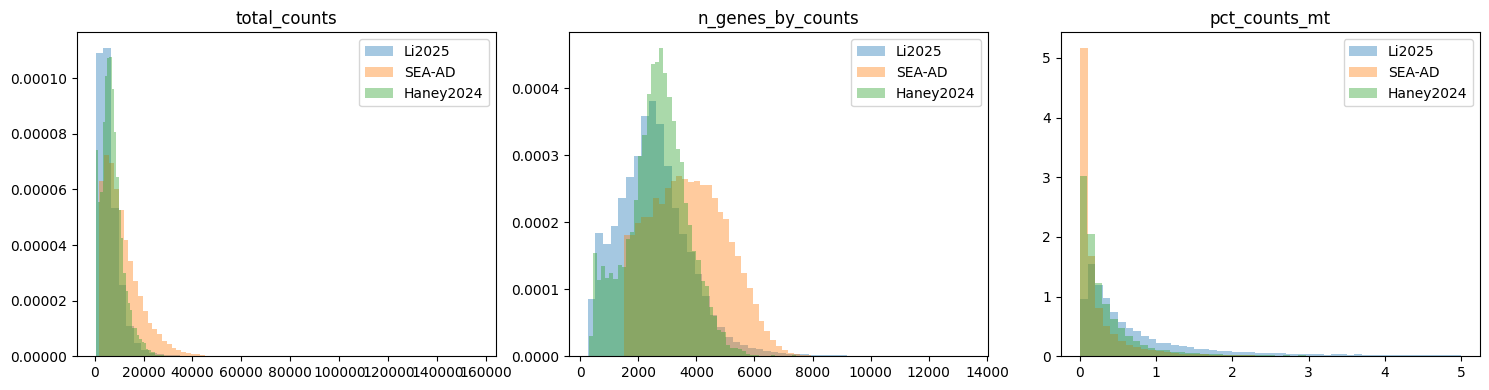

In [12]:
# Are the study-pure clusters explained by depth / mito / doublets rather than biology?
QC_COLS = [c for c in ["total_counts", "n_genes_by_counts", "pct_counts_mt"]
           if c in astro.obs.columns]
print("per-cluster QC medians (astro):")
print(astro.obs.groupby("leiden_scvi")[QC_COLS].median().loc[ASTRO_CLUSTERS].round(2))

# carried-forward niche-mito diagnostic: among ANNOTATED astrocytes, does pct_counts_mt pile up
# against the 5% ceiling - especially in Li / Haney, which had no labels at QC time?
print("\nastrocyte pct_counts_mt by study:")
g = astro.obs.groupby("study_id")["pct_counts_mt"]
mito = pd.DataFrame({
    "mean": g.mean().round(2),
    "p95":  g.quantile(0.95).round(2),
    "frac_over_5pct": astro.obs.assign(o=astro.obs["pct_counts_mt"] > 5)
                       .groupby("study_id")["o"].mean().round(3),
})
print(mito)

fig, axes = plt.subplots(1, len(QC_COLS), figsize=(5*len(QC_COLS), 4))
for a_, col in zip(np.atleast_1d(axes), QC_COLS):
    for st in astro.obs["study_id"].unique():
        a_.hist(astro.obs.loc[astro.obs["study_id"]==st, col], bins=50, alpha=0.4,
                label=st, density=True)
    a_.set_title(col); a_.legend()
plt.tight_layout(); plt.show()

> **Interpretation — Lever 4 — QC covariates + niche-mito (6d).**
>
> **Per-cluster QC medians — only one cluster is QC-driven.** Most astrocyte clusters sit in a tight band (ca. 6–9k counts, 2.5–3.5k genes, mito < 0.8%). The exception is **cl45: 21,126 counts / 4,835 genes** — roughly 3× the depth of any other cluster — confirming it is a **high-depth technical cluster**, its SEA-purity an artifact of unusually rich libraries from one donor (the 6b single-donor read), not a distinct astrocyte biology. The other two suspects are NOT QC outliers: **cl22** (7,542 counts / 0.32% mito) and **cl42** (8,909 counts / 0.06% mito) sit squarely in the normal band — important, because it means cl22's ambient nature is *cross-contamination* (extra myelin transcripts riding on otherwise healthy nuclei), not low-quality cells, so a QC lever correctly does not flag it. cl33's mito (0.76%) is the highest of the eight but still nowhere near the 5% ceiling.
>
> **The carried-forward niche-mito diagnostic is NEGATIVE: `frac_over_5pct = 0.0` in all three studies** (astrocyte pct_counts_mt mean Li 0.79 / SEA 0.27 / Haney 0.40; p95 ≤ 2.9%). No astrocyte mito pile-up against the 5% ceiling in any study — including the label-free Li and Haney — so **mito is cleared** as a driver of the study-pure clusters and the setup-audit worry is closed.
>
> **The histograms (figure) show modest study-level technical offsets, not cluster-making ones.** `total_counts`: all three peak low and right-skew, SEA-AD carrying a slightly longer high-depth tail. `n_genes_by_counts`: SEA-AD is shifted right (peak ca. 3,500–4,000 genes vs ca. 2,500–3,000 for Li/Haney) — SEA-AD simply has richer libraries. `pct_counts_mt`: all three pile near zero (SEA-AD the sharpest spike, Li a marginally fatter low tail), all far under 5%. These are global, study-wide differences — the kind scVI absorbs in latent space and the FM handles via its own depth normalization downstream — and crucially they are *not* localized to the suspect clusters, so they do not explain the study-purity of cl22 / 33 / 42.
>
> **What 6d licenses:** cl45 → **technical (high-depth)**, settled here; mito globally cleared; cl22, cl33 and cl42 pass QC and stay live for the program levers (6e/6f), where their mechanism gets decided.

### 6e — Lever 3: DE program coherence + over-clustering check

The most informative lever: run differential expression of each suspect against the mixed-ref backbone and **read what kind of genes are driving its purity.** A coherent astrocyte program (reactive/DAA — GFAP, CD44, SERPINA3, C3, VIM; or homeostatic — SLC1A2, GLUL) points to **real biology**; a list dominated by technical genes points to **batch**, and the panel names *which* technical kind.

**Named nuisance panels instead of one opaque number.** Each top up-gene is classified into `ribo_mito` (MT-/RPL/RPS/MALAT1 — depth and mitochondrial contamination), `ambient` (neuronal transcripts SNAP25/RBFOX3/MEG3/NRGN/SYT1 that bleed in during dissociation), `sex` (XIST/Y-genes, a study sex-imbalance nuisance), or `biological`. A single `tech_frac` would hide which nuisance is acting; the split says so.

**A caveat baked into the label — `biological` means "not a *tracked* nuisance," not "real astrocyte."** A cluster driven by oligodendrocyte myelin genes is lineage contamination, but myelin genes are not ribo/mito/sex, so the panel scores them `biological`. That gap is exactly why the gene list is printed in full and read by eye, not just summarized by the fractions.

**Fail-loud guard.** If `var_names` were Ensembl IDs (or used a different mito naming convention), the nuisance regex would match nothing, every fraction would read 0, and every cluster would look falsely biological. The `assert` refuses to proceed unless the regex finds ≥5 ribo/mito genes, MALAT1, and an `MT-` gene — so a silent label mismatch cannot masquerade as a clean result.

**Over-clustering check.** cl33/42/45 could be three real programs, or one astrocyte state the clustering split three ways. The cell takes each pair's top-20 markers and computes their Jaccard overlap — high overlap = one state over-split (merge); low = genuinely distinct. Both DE runs use `mixed_ref` as reference, not `rest`, for the reason fixed in 6a: `rest` would contain the sibling suspects and cancel any shared program, faking a low Jaccard.

In [13]:
import re
# Decompose each study-pure cluster's DE vs the MIXED astro reference into NAMED nuisance panels,
# reported separately -- a coherent astrocyte program (reactive/DAA: GFAP/CD44/SERPINA3/C3/VIM;
# homeostatic: SLC1A2/GLUL) -> biology; ribo/mito, neuronal-ambient, or sex domination -> the
# specific kind of batch. One opaque tech_frac hides WHICH nuisance is driving study-purity.
RIBO_MITO_PAT = r"^(MT-|RPL|RPS|MRPL|MRPS)|^MALAT1$"
AMBIENT = {"SNAP25", "RBFOX3", "MEG3", "NRGN", "SYT1"}           # neuronal ambient / dissociation
SEX     = {"XIST", "DDX3Y", "UTY", "EIF1AY", "KDM5D", "RPS4Y1"}  # study sex-imbalance nuisance

def classify(name):
    name = str(name)
    if name in SEX:     return "sex"        # checked first: RPS4Y1 also matches ^RPS
    if name in AMBIENT: return "ambient"
    if re.match(RIBO_MITO_PAT, name): return "ribo_mito"
    return "biological"
NUISANCE = {"sex", "ambient", "ribo_mito"}  # reused by 6f to filter the replication signature

# fail-loud guard: if var_names aren't gene symbols (e.g. Ensembl IDs) or use a different mito
# convention, the regex silently matches nothing -> fractions read 0 -> every cluster looks
# biological. Refuse to trust the readout in that case.
_vn = astro.var_names.astype(str)
_n_ribo = _vn.str.match(RIBO_MITO_PAT).sum()
assert _n_ribo >= 5 and "MALAT1" in set(_vn) and _vn.str.startswith("MT-").any(), (
    f"nuisance regex matched too few genes (ribo/mito={_n_ribo}, "
    f"MALAT1 present={'MALAT1' in set(_vn)}, MT- present={_vn.str.startswith('MT-').any()}). "
    "Are var_names gene symbols, not Ensembl IDs? Refusing to trust nuisance fractions.")

astro.obs["batch_grp"] = np.where(astro.obs["leiden_scvi"].isin(MIXED), "mixed_ref",
                                  astro.obs["leiden_scvi"].astype(str))
X_raw = astro.X; astro.X = astro.layers["lognorm"]
try:
    sc.tl.rank_genes_groups(astro, groupby="batch_grp", groups=LI_PURE + SEA_PURE,
                            reference="mixed_ref", method="wilcoxon", n_genes=50, use_raw=False)
finally:
    astro.X = X_raw
for cl in LI_PURE + SEA_PURE:
    de = sc.get.rank_genes_groups_df(astro, group=cl)
    de = de[de["pvals_adj"] < 0.05]                    # drop non-significant high-LFC noise genes
    up = de.sort_values("logfoldchanges", ascending=False).head(20)
    fr = up["names"].map(classify).value_counts(normalize=True)
    print(f"\n--- cluster {cl} vs mixed_ref --- top-20 up: "
          f"ribo/mito={fr.get('ribo_mito',0):.2f}  ambient={fr.get('ambient',0):.2f}  "
          f"sex={fr.get('sex',0):.2f}  biological={fr.get('biological',0):.2f}")
    print(up[["names", "logfoldchanges", "pvals_adj"]].to_string(index=False))

# over-clustering check (cause c): are 33/42/45 three distinct programs or one state split 3 ways?
# compare each SEA-pure cluster to the SAME neutral mixed_ref - NOT to default "rest", which
# contains the sibling SEA-pure clusters and would cancel their shared program out of the top
# markers -> falsely low Jaccard -> falsely "distinct programs".
X_raw = astro.X; astro.X = astro.layers["lognorm"]
try:
    sc.tl.rank_genes_groups(astro, groupby="batch_grp", groups=SEA_PURE,
                            reference="mixed_ref", method="wilcoxon", n_genes=25, use_raw=False)
finally:
    astro.X = X_raw
def _sig_top(cl, n=20):
    d = sc.get.rank_genes_groups_df(astro, group=cl)
    d = d[d["pvals_adj"] < 0.05]
    return set(d.sort_values("logfoldchanges", ascending=False).head(n)["names"])
tops = {cl: _sig_top(cl) for cl in SEA_PURE}
print("\nSEA-pure pairwise top-20 marker Jaccard (high -> over-clustering of one state):")
for i in range(len(SEA_PURE)):
    for j in range(i+1, len(SEA_PURE)):
        a_, b_ = SEA_PURE[i], SEA_PURE[j]
        jac = len(tops[a_] & tops[b_]) / len(tops[a_] | tops[b_])
        print(f"  {a_} vs {b_}: {jac:.2f}")


--- cluster 22 vs mixed_ref --- top-20 up: ribo/mito=0.00  ambient=0.00  sex=0.00  biological=1.00
   names  logfoldchanges  pvals_adj
   ELMO1        6.674301        0.0
    ST18        6.474086        0.0
  FRMD4B        6.325358        0.0
    PLD1        6.313999        0.0
   KCNH8        6.125913        0.0
    GLDN        5.967307        0.0
    MOBP        5.953628        0.0
  DOCK10        5.886299        0.0
   ENPP2        5.877609        0.0
  ZNF536        5.533508        0.0
     MBP        5.400726        0.0
  CTNNA3        5.289531        0.0
   EDIL3        5.049839        0.0
    PLP1        5.042449        0.0
 SLC24A2        5.031040        0.0
  SPOCK3        4.988423        0.0
ARHGAP22        4.960101        0.0
 SYNDIG1        4.948672        0.0
IL1RAPL1        4.814612        0.0
    SPP1        4.775216        0.0

--- cluster 33 vs mixed_ref --- top-20 up: ribo/mito=0.05  ambient=0.00  sex=0.00  biological=0.95
     names  logfoldchanges     pvals_adj
 LI

> **Interpretation — Lever 3 — DE program coherence + over-clustering (6e).**
>
> **The statistic.** This DE uses **Wilcoxon** (ca. 54 min on the 94k-astrocyte subset — affordable here, unlike the full-694k object where it timed out >3h and 4a fell back to a t-test), so unlike 4a these gene rankings are the defensible ones. Top-20 up-genes vs **mixed_ref**, with the named nuisance fractions printed per cluster.
>
> **The automated nuisance panels come back near-clean for every suspect** (ribo/mito 0.00–0.05, ambient 0.00, sex 0.00) — so none of cl22/33/42/45 is driven by a *tracked* technical panel. The discrimination therefore comes from reading *which biological program* each list encodes:
>
> - **cl22 — oligodendrocyte/myelin, i.e. ambient bleed (the caveat in action).** Its top genes are the structural proteins of myelin and oligodendrocyte identity: MOBP, MBP, PLP1 (myelin-sheath proteins), plus CTNNA3, ST18, ELMO1, GLDN. The panel scores this `biological=1.00`, but that only means "no tracked nuisance" — these are not astrocyte genes at all. It is free-floating myelin transcript from lysed oligodendrocytes contaminating astrocyte nuclei → **ambient**, confirming the 4b astro/oligo near-tie and the 6b many-donor read. This slip-through is exactly the scenario the pre-code caveat warned about.
> - **cl33 — a coherent metabolic / circadian program:** NPAS2 (a core circadian-clock transcription factor), SOD2 (mitochondrial superoxide dismutase, oxidative-stress defense), PFKP (rate-limiting glycolytic enzyme), SLC38A2 (glutamine transporter), CACNA1D. No nuisance signature — a real, internally coherent astrocyte state. This is the cluster 6f goes on to rescue as **real-but-confounded**.
> - **cl42 — heat-shock / chaperone program:** HSPE1, HSPB1, DNAJB1, HSPH1, HSPA1B, HSPA1A, HSP90AA1, CRYAB — the classic dissociation-stress signature (cells heat-shocking during tissue processing). Coherent, but a technical-stress program tied to one donor's sample handling → **donor effect**.
> - **cl45 — mito / high-depth flavoured:** MTRNR2L12 (a mitochondrially-derived pseudogene) and MT-ATP8 head the list, consistent with the 21k-count high-depth read in 6d → **technical / donor**.
>
> **Over-clustering rejected.** SEA-pure pairwise top-20 Jaccard = **0.05** for all three pairs (33v42, 33v45, 42v45) — almost no marker overlap, so these are three *distinct* programs (metabolic / heat-shock / high-depth), not one astrocyte state the clustering split three ways. No merge.
>
> **What 6e licenses:** cl22 = ambient (nailed by the gene list), cl42 = donor stress, cl45 = technical/depth — three suspects mechanistically explained; cl33 stands out as the one coherent biological program with no technical tell, set up for the cross-study replication test in 6f.

### 6f — Lever 2: cross-study program replication

The decisive lever for separating a **real but study-confounded** astrocyte state from a **study-unique** artifact. The logic: turn each suspect cluster's program into a gene signature, score *every* astrocyte for it, and ask whether the program shows up — even faintly, as a tail — in the **other** studies. A real astrocyte substate should exist everywhere, just at different abundance (a shared tail across studies → differential abundance, keep); a batch/technical effect is **categorically absent** outside its source study (→ scrub or caveat).

**Two design safeguards, both load-bearing:**

- **Nuisance-filtered signature.** Each signature is built from a cluster's top up-genes *after* dropping the 6e nuisance panels (ribo/mito, neuronal-ambient, sex). The replication test then runs on the candidate *biology*, not on the technical genes that already explain the study-purity — otherwise a shared depth artifact could fake "replication."
- **Non-circular primary readout.** A signature is enriched in its own source cluster by construction, so averaging it over *all* astrocytes of the source study is partly circular — the cluster inflates its own study's mean. The **primary** test therefore scores only the **mixed-ref** astrocytes (the well-mixed backbone, which excludes all four suspect clusters) and asks whether the program survives in that shared background, study by study. The all-astrocyte version is printed second, explicitly labeled circular, as a check on how much self-inflation the primary readout removed.

The histograms overlay each program's score distribution across the three studies, so a program present everywhere (overlapping curves) is visually distinct from one isolated to a single study (one curve shifted off the others).

PRIMARY - program score in MIXED-REF astrocytes by study (non-circular replication test):
           prog_22  prog_33  prog_42  prog_45
study_id                                     
Li2025      -0.060    0.114   -0.046   -0.044
SEA-AD      -0.125    0.231    0.059    0.308
Haney2024   -0.094    0.139    0.048   -0.062

secondary - program score over ALL astrocytes by study (source study inflated by own cluster):
           prog_22  prog_33  prog_42  prog_45
study_id                                     
Li2025       0.093    0.111   -0.050   -0.056
SEA-AD      -0.122    0.268    0.088    0.324
Haney2024   -0.089    0.139    0.047   -0.062


/tmp/ipykernel_3740/2094301886.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(mref.groupby("study_id")[prog_cols].mean().round(3))
/tmp/ipykernel_3740/2094301886.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(astro.obs.groupby("study_id")[prog_cols].mean().round(3))


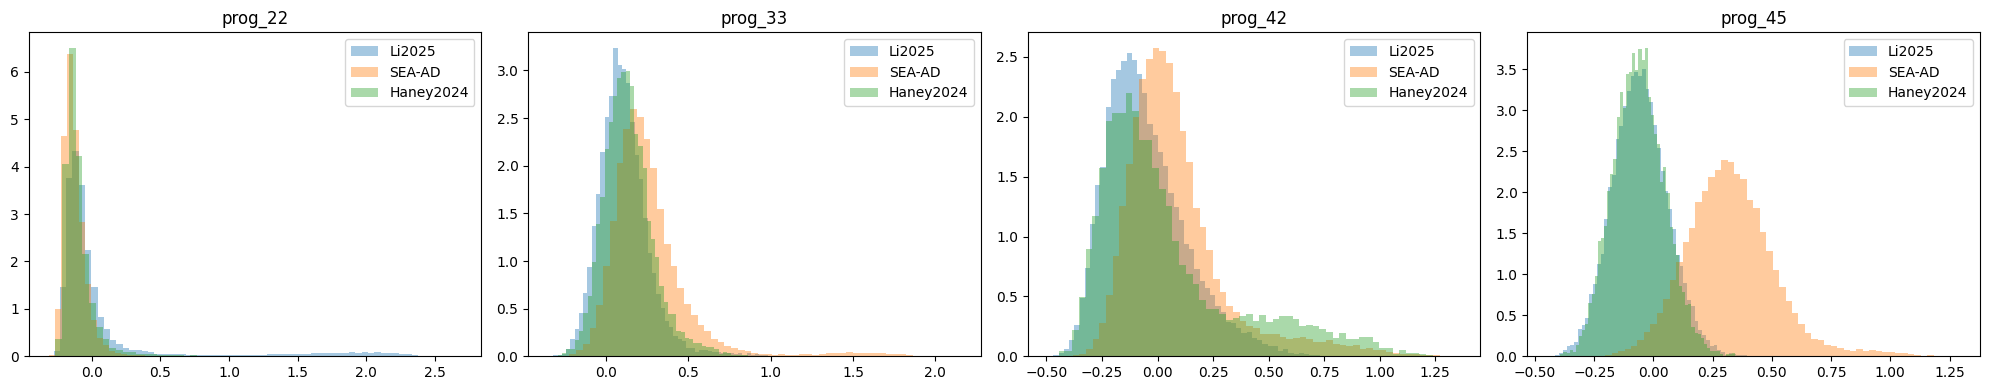

In [14]:
# Build a (nuisance-filtered) signature from each study-pure cluster's top up-genes, score ALL
# astrocytes, and ask: does the program appear as a TAIL in the other studies (real substate,
# differential abundance) or is it CATEGORICALLY absent elsewhere (batch / study-unique technical)?
# Filter ribo/mito + neuronal-ambient + sex (the 6e panels) so the tested residual is the candidate
# biology, not the nuisance that already explains study-purity.
X_raw = astro.X; astro.X = astro.layers["lognorm"]
try:
    sc.tl.rank_genes_groups(astro, groupby="batch_grp", groups=LI_PURE + SEA_PURE,
                            reference="mixed_ref", method="wilcoxon", n_genes=80, use_raw=False)
    sigs = {}
    for cl in LI_PURE + SEA_PURE:
        de = sc.get.rank_genes_groups_df(astro, group=cl)
        de = de[de["pvals_adj"] < 0.05]                        # significant only (drop LFC noise)
        de = de[de["names"].map(classify) == "biological"]     # drop ribo/mito + ambient + sex
        sigs[cl] = de.sort_values("logfoldchanges", ascending=False).head(30)["names"].tolist()
    for cl, gs in sigs.items():
        sc.tl.score_genes(astro, gene_list=gs, score_name=f"prog_{cl}", use_raw=False)
finally:
    astro.X = X_raw
prog_cols = [f"prog_{cl}" for cl in LI_PURE + SEA_PURE]
# PRIMARY (non-circular): score ONLY the well-mixed reference astrocytes, split by study. The
# signature is by construction enriched in the source study's pure cluster, so a mean over ALL
# astrocytes is partly circular (the cluster inflates its own study's mean). Whether the program
# shows up in the SHARED mixed background of the OTHER studies is the real replication test.
mref = astro.obs[astro.obs["batch_grp"] == "mixed_ref"]
print("PRIMARY - program score in MIXED-REF astrocytes by study (non-circular replication test):")
print(mref.groupby("study_id")[prog_cols].mean().round(3))
print("\nsecondary - program score over ALL astrocytes by study (source study inflated by own cluster):")
print(astro.obs.groupby("study_id")[prog_cols].mean().round(3))

fig, axes = plt.subplots(1, len(prog_cols), figsize=(5*len(prog_cols), 4))
for a_, col in zip(np.atleast_1d(axes), prog_cols):
    for st in astro.obs["study_id"].unique():
        a_.hist(astro.obs.loc[astro.obs["study_id"]==st, col], bins=60, alpha=0.4,
                label=st, density=True)
    a_.set_title(col); a_.legend()
plt.tight_layout(); plt.show()

> **Interpretation — Lever 2 — cross-study program replication (6f).**
>
> This is the lever that **rescues cl33 and condemns the rest.** Read the PRIMARY table (mean program score in *mixed-ref* astrocytes only — the suspect clusters are excluded, so a positive value means the program is present in a study's shared astrocyte background, not in the source cluster):
>
> - **prog_22 — replicates nowhere.** Negative in all three studies (Li −0.060 / SEA −0.125 / Haney −0.094). The cl22 program is absent from every study's shared astrocyte background → not a real astrocyte state → seals the **ambient/doublet** verdict (with 6b's 106 donors and 6e's myelin genes).
> - **prog_33 — the one program that replicates.** Positive in all three (Li +0.114 / SEA +0.231 / Haney +0.139). Even though cl33 is 99% one SEA donor, its metabolic program is detectable in the Li and Haney astrocyte backgrounds too → a **real astrocyte state confounded with a SEA donor** → `real_confounded`, **KEEP** (do not scrub; carry the confound caveat into eval#2).
> - **prog_42 — weak, SEA-leaning.** Near zero, faintly positive only in SEA/Haney (Li −0.046 / SEA +0.059 / Haney +0.048) → not a convincing shared state → **donor/stress** (the 6e heat-shock program).
> - **prog_45 — SEA-isolated.** Strongly positive in SEA (+0.308) but negative in Li (−0.044) and Haney (−0.062). It is elevated across the SEA *backbone*, not just cl45 — yet it is **categorically absent from the other two studies**, the batch/study-unique technical signature rather than a shared substate → **technical/donor** (the 6e mito/high-depth program).
>
> **The histograms (figure, all astrocytes per study) make the same split visible.** prog_22: all three curves collapse on top of each other at ~0 (the long thin right tail is just the cl22 cells themselves) — no study structure. prog_33: all three curves sit positive of zero and overlap heavily, SEA shifted only slightly further right — present everywhere. prog_42: curves mostly overlap near zero with a modest SEA shift and a small Haney positive shoulder — weak. prog_45: the clean separation — SEA (orange) shifted well right (peak ca. +0.3) while Li and Haney pile at/below zero — a single-study program.
>
> **Secondary (all-astro, circular) corroborates the design.** prog_22 flips from −0.060 (primary) to **+0.093 in Li** (secondary) — positive *only because cl22's own Li cells are back in the average*, the exact self-inflation the mixed-ref primary readout strips out. Concrete evidence the mixed-ref (non-circular) contrast changed a reading.
>
> **What 6f licenses (and closes the battery):** cl22 ambient, cl42 donor-stress, cl45 technical — all study-unique; cl33 the lone real-but-confounded astrocyte state. The astrocyte residual-batch is therefore **not a study-level integration failure** — one genuine confounded biological cluster plus three explained nuisances — which is exactly why the gated 2nd-scVI in 6g is NOT tripped.

### 6g — Lever 6 (GATED): 2nd-scVI on the glia subset

The last and most consequential lever, and the only one that is **gated** — it runs *only* if 6b–6f returned a BATCH verdict. The reason it is gated rather than always-on: re-integration is a second round of batch correction, and batch correction is **not free** — it actively removes whatever variation aligns with `study_id`, including *real* biology that happens to be study-confounded. Running it reflexively "just in case" would over-correct and erase the genuine cl33 metabolic program that 6f just established is real. So the design refuses to re-integrate unless the battery has affirmatively diagnosed batch; correcting an artifact you have not confirmed is itself an error.

**What it would do if tripped.** Re-integrate the glia subset *alone* — not the full 694k object — so scVI's modeling capacity concentrates on glial structure instead of being dominated by the neuron majority (the hierarchical 2nd-scVI-on-subset path reserved in the integration lock). Same recipe as colab_04: 3,000 study-batched HVGs, niche genes (APOE/TREM2/…/CSF1R) force-injected, `n_latent=30`, `n_layers=2`, `gene_likelihood="nb"`, then re-cluster and re-cross-tab the astrocytes.

**The decisive read.** Do the study-pure clusters (cl22; cl33/42/45) **dissolve** into the mixed astrocyte manifold after a second correction (→ they were batch, now fixed) or **persist** as their own clusters (→ not simple batch — real structure the first integration left intact)? `RUN_2ND_SCVI` is the switch; it stays `False` unless 6b–6f point to batch.

In [15]:
RUN_2ND_SCVI = False   # <- flip to True ONLY on a BATCH verdict from 6b-6f

if RUN_2ND_SCVI:
    import torch, scvi
    assert torch.cuda.is_available(), "2nd-scVI needs a GPU runtime"
    scvi.settings.seed = 0
    g2 = glia.copy()   # re-integrate glia ALONE: capacity focuses on glia, not the neuron majority
    sc.pp.highly_variable_genes(g2, flavor="seurat_v3", n_top_genes=3000,
                                batch_key="study_id", subset=False)
    NICHE = ["APOE", "TREM2", "MS4A6A", "CLU", "GFAP", "AQP4", "AIF1", "CSF1R"]
    for gname in NICHE:
        if gname in g2.var_names:
            g2.var.loc[gname, "highly_variable"] = True
    g2_hvg = g2[:, g2.var["highly_variable"]].copy()
    scvi.model.SCVI.setup_anndata(g2_hvg, batch_key="study_id")
    m2 = scvi.model.SCVI(g2_hvg, n_latent=30, n_layers=2, gene_likelihood="nb")
    m2.train(max_epochs=200, early_stopping=True, early_stopping_patience=15)

    glia.obsm["X_scVI_glia"] = m2.get_latent_representation(g2_hvg)
    del g2, g2_hvg; gc.collect()
    sc.pp.neighbors(glia, use_rep="X_scVI_glia", n_neighbors=15)
    sc.tl.leiden(glia, resolution=1.0, key_added="leiden_glia", flavor="igraph",
                 n_iterations=2, directed=False)
    sc.tl.umap(glia, min_dist=0.3)

    re_astro = glia[glia.obs["cell_type"] == "astrocyte"]
    print("re-integrated astro cluster x study (did 22 / 33,42,45 dissolve?):")
    print(pd.crosstab(re_astro.obs["leiden_glia"], re_astro.obs["study_id"], normalize="index").round(3))
    sc.pl.umap(re_astro, color=["study_id", "leiden_glia", "leiden_scvi"], ncols=3, show=True)

    glia.write_h5ad(GLIA_PATH)   # persist re-integrated latent for the FM notebooks
    print("re-integrated latent (X_scVI_glia) saved ->", GLIA_PATH)
else:
    print("2nd-scVI skipped - gated by design; verdict from 6b-6f was not BATCH.")

2nd-scVI skipped - gated by design; verdict from 6b-6f was not BATCH.


> **Interpretation — Lever 6 (gated) — 2nd-scVI (6g).**
>
> **Skipped, and skipping is the correct scientific action — not an omission.** The output reads `2nd-scVI skipped - gated by design`. The combined 6b–6f verdict is **single-donor (cl42, cl45) + ambient (cl22) + one real-but-confounded state (cl33)** — three explained nuisances and one genuine biological cluster, none of which is a study-level batch failure. The gate's precondition (a BATCH verdict) was never met, so `RUN_2ND_SCVI` correctly stayed `False`.
>
> **Why running it would have been a mistake.** A second integration would have pulled cl33's metabolic program toward the study mean precisely *because* that program is SEA-confounded — over-correcting the one signal 6f proved is real, and trading a clean, interpretable cluster for a falsely "well-mixed" one. The cost of an unnecessary correction is destroyed biology, which is exactly what the gate exists to prevent.
>
> **What the residual-batch flag actually licenses (pre-registered).** The astrocyte study-purity is real but its consequence is **eval-integrity**, not substrate corruption: cl33's donor/study confound can leak into eval#2 (APOE recovery from ~4k donor-pure cells), so the action is to **caveat eval#2 and carry the confound forward to colab_06**, not to re-integrate. The CPT substrate itself (raw counts over all astrocytes) is untouched — the flag never threatened it. 6g closing the battery un-tripped is the formal confirmation that Section 6 ends in `not_study_batch`.

## 7 — Audit C re-check (145-donor set)

colab_04's 5c dropped 21 intermediate-ADNC donors (all SEA-AD, the ambiguous-pathology cases), shrinking the cohort to **145 donors**. That changes the donor arithmetic the eval splits depend on, so Audit C — the donor-count feasibility check first run in the setup audits — is re-run here against the post-drop set before any eval is committed.

### 7a — Donor counts per (disease × APOE × study) stratum

eval#2 (the Stanton-core APOE-axis recovery) is a **donor-level** test: it asks whether APOE-carrier and noncarrier donors separate within astrocytes and within microglia. Its statistical power is therefore set by **how many donors land in each APOE group of the held-out TEST set**, not by how many cells. This cell checks that the donor-level 70/15/15 split (stratified by disease × APOE × study, with a global held-out set shared across all regimes) still has enough test donors after the 5c drop.

It reports at **two deliberately different granularities**, answering different questions:

- **Fine — per (study × diagnosis × APOE-carrier).** This guards split *representativeness*: that the APOE × study confound does not leak into the held-out set. At 145 donors, `floor(0.15 × n)` is < 3 for almost every fine stratum, so the PINCH tripwire fires on nearly all of them — **expected, and not alarming, because no eval actually consumes this granularity.** It is a confound-leak guard, not a power calculation.
- **Coarse — per (APOE-carrier), and per (diagnosis × APOE-carrier), pooled across study.** This is the eval#2-facing number: eval#2 pools studies and recovers the APOE axis within each cell type, so donors-per-APOE-group in TEST is the real power constraint — the count that decides whether eval#2 has legs.

`floor` (not round) is used throughout as a conservative tripwire — it under-counts rather than over-promises test donors. A final glia-cell table per (cell_type × APOE) backstops the donor counts, so a donor nominally present but contributing near-zero niche cells cannot inflate apparent support.

In [16]:
# colab_04 5c dropped 21 intermediate-ADNC donors (all SEA-AD). Re-check that the donor-level
# 70/15/15 split stratified by disease x APOE x study still leaves >=3 donors per TEST stratum.
donors = (adata.obs[["donor_id", "diagnosis", "apoe_carrier", "study_id"]]
          .drop_duplicates("donor_id"))
print("total donors:", len(donors), " by study:", donors["study_id"].value_counts().to_dict())
strata = donors.groupby(["study_id", "diagnosis", "apoe_carrier"]).size().rename("n_donors")
print("\ndonors per (study x diagnosis x APOE-carrier) stratum:")
print(strata.to_frame())

TEST_FRAC = 0.15
strata_test = np.floor(strata * TEST_FRAC).astype(int)   # floor = conservative feasibility tripwire
pinch = strata_test[strata_test < 3]
if len(pinch):
    print("\n[AUDIT C - PINCH] strata with <3 expected test donors. Locked fallback: collapse "
          "APOE -> 'any-e4', else drop the thinnest study:")
    print(pinch.to_frame("expected_test_donors"))
else:
    print("\n[AUDIT C] all strata >=3 expected test donors - split is safe.")

# Eval-facing coarse check: the per-(study x disease x APOE) granularity above guards split
# REPRESENTATIVENESS (APOE x study confound not leaking into held-out), but no eval consumes it.
# eval#2 recovers the APOE axis WITHIN astro / WITHIN micro, POOLED across study -> the binding
# constraint for eval#2 power is donors per APOE-carrier group in TEST. At this donor count the
# per-stratum check fires near-universally (all Haney strata); this coarser number is the one
# that says whether eval#2 still has legs after the fallback.
for keys in (["apoe_carrier"], ["diagnosis", "apoe_carrier"]):
    c_test = np.floor(donors.groupby(keys).size() * TEST_FRAC).astype(int)
    print(f"\n[eval#2-facing] expected TEST donors per ({' x '.join(keys)}):")
    print(c_test.to_frame("expected_test_donors"))
    thin = c_test[c_test < 3]
    if len(thin):
        print("  -> wide donor-level error bars expected for eval#2 here:", thin.index.tolist(),
              "\n     (N=3 seeds do NOT fix this -- seeds vary LoRA/RNG, the donor split is fixed)")

# secondary: a donor with ~0 astro/micro cells in test contributes nothing -- show cells available
# per (cell_type x APOE-carrier) so thin counts diluting nominal donor presence don't slip through.
if "glia" in globals():
    print("\n[eval#2-facing] glia cells per (cell_type x APOE-carrier) (full set, pre-split):")
    print(glia.obs.groupby(["cell_type", "apoe_carrier"]).size().rename("n_cells").to_frame())

total donors: 145  by study: {'SEA-AD': 63, 'Li2025': 56, 'Haney2024': 26}

donors per (study x diagnosis x APOE-carrier) stratum:
                                  n_donors
study_id  diagnosis apoe_carrier          
Li2025    AD        carrier             11
                    e2                   8
                    noncarrier          10
          Control   carrier              8
                    e2                   9
                    noncarrier          10
SEA-AD    AD        carrier             20
                    e2                   1
                    noncarrier          21
          Control   carrier              0
                    e2                   7
                    noncarrier          14
Haney2024 AD        carrier             10
                    e2                   0
                    noncarrier           8
          Control   carrier              0
                    e2                   0
                    noncarrier           8

[AUDIT C

/tmp/ipykernel_3740/1961271042.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  strata = donors.groupby(["study_id", "diagnosis", "apoe_carrier"]).size().rename("n_donors")
/tmp/ipykernel_3740/1961271042.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  c_test = np.floor(donors.groupby(keys).size() * TEST_FRAC).astype(int)
/tmp/ipykernel_3740/1961271042.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  c_test = 

> **Interpretation — Audit C — eval#2 donor feasibility (7a).**
>
> **The cohort:** 145 donors (SEA-AD 63 / Li 56 / Haney 26), every donor classified into a disease × APOE × study stratum (the strata sum exactly to 145).
>
> **The fine PINCH list is loud but expected.** `floor(0.15 × n) < 3` fires for almost every (study × diagnosis × APOE) stratum — e.g. Li AD-carrier (11 donors → 1 expected test), SEA AD-e2 (1 → 0), SEA Control-carrier (0 → 0). This is **not** an eval failure: no eval consumes per-(study × disease × APOE) granularity. The fine check only guards that the APOE × study confound is not silently concentrated in the held-out set, and it does its job by flagging where representativeness is thin.
>
> **The eval#2-facing coarse numbers are the ones that matter, and the binary E4 axis is workable:** pooled across study, the held-out TEST set is expected to carry **carrier 7 / noncarrier 10** donors (e2 arm 3, kept separate, not merged into carrier) — enough to estimate an APOE-carrier vs noncarrier separation within astrocytes and within microglia.
>
> **Where eval#2 will be weak, stated honestly.** Split further by diagnosis, three strata go thin: **AD-e2 (1 expected test donor), Control-carrier (1), Control-e2 (2)** — driven by SEA-AD contributing 0 Control-carriers and only 1 AD-e2, and Haney 0 e2 / 0 Control-carrier donors. eval#2 will have **wide donor-level error bars** in those cells, and crucially **N=3 seeds cannot fix this** — seeds vary LoRA initialization and RNG, but the donor split is fixed, so re-seeding re-samples nothing at the donor level. The locked fallback if a needed stratum drops below 3 test donors: collapse APOE → "any-e4", else drop the thinnest study.
>
> **Donor count, not cell count, is the binding constraint.** The glia-cell table is ample in every APOE group (astro carrier 32,407 / e2 14,846 / noncarrier 47,018; micro carrier 18,770 / e2 9,073 / noncarrier 27,261), so no APOE group is cell-starved — the limit on eval#2 power is purely how many *donors* fall in each test group. That is the secondary guard's point: plenty of cells cannot rescue an axis that has too few donors behind it.

## 8 — Verdict + audit trace + handoff

The battery is complete; this section commits its conclusion. It writes the annotation and the per-cluster adjudication verdict into the cumulative `audit_report.json`, sorts the artifacts into committable vs Drive-only, prints the manual commit/push commands, and hands the open items to colab_06.

### 8a — Write annotation + adjudication trace; commit instructions

This cell computes nothing new — it **records the verdict and its provenance** so the decision is auditable later. It extends the single cumulative `audit_report.json` (the one-file-per-project artifact each notebook appends to, set up in the setup audits) with two blocks: an `annotation` block (final cell counts, per-cell-type tallies, the glia-subset path) and an `astro_batch_adjudication` block (the overall `not_study_batch` verdict, the per-cluster verdicts, the `ran_2nd_scvi` flag, and a prose `notes` trace citing the specific lever evidence behind each call).

The per-cluster verdict strings are filled in here, in the `_OUTPUT`, *after* a human has read levers 6b–6f against the pre-registered decision map — the code surfaces the evidence, the adjudication is the analyst's call, and writing it into the JSON freezes it.

Finally it sorts artifacts by storage policy — **committable** (the pip-freeze, the env JSON, the audit report — all small, all version-controlled) vs **Drive-only** (the 6.53 GB glia subset, too large to commit) — and prints the exact `git add/commit/push` commands, run by hand from WSL because the Colab runtime has no git credentials.

In [17]:
import shlex
AUDIT_REPORT_PATH = os.path.join(REPO_PATH, "outputs", "audit_report.json")
with open(AUDIT_REPORT_PATH) as f:
    report = json.load(f)

report["annotation"] = {
    "status": "computed",
    "date": TODAY,
    "n_cells": int(adata.n_obs),
    "cell_type_counts": adata.obs["cell_type"].value_counts().to_dict(),
    "n_astrocytes": int((adata.obs["cell_type"] == "astrocyte").sum()),
    "n_microglia":  int((adata.obs["cell_type"] == "microglia").sum()),
    "glia_subset_path": GLIA_PATH,
}
# verdict + notes filled in _OUTPUT after reading Levers 6b-6f (one of: batch / real_confounded /
# over_clustering / donor_effect / ambiguous). Pre-registered decision map in What we did.txt.
report["astro_batch_adjudication"] = {
    "status": "computed",
    "date": TODAY,
    "li_pure_clusters": LI_PURE,
    "sea_pure_clusters": SEA_PURE,
    "verdict": "not_study_batch",
    "per_cluster_verdict": {
        "22": "ambient",
        "33": "real_confounded",
        "42": "donor_effect",
        "45": "donor_effect",
    },
    "ran_2nd_scvi": bool(RUN_2ND_SCVI),
    "notes": (
        "Within-niche astrocyte study-purity does NOT reflect a study-level batch failure, "
        "so the 6g 2nd-scVI gate was correctly not tripped. Per-cluster (weight-of-evidence): "
        "cl22 (Li-pure) = ambient -- 6e top markers are oligodendrocyte myelin "
        "(ELMO1/ST18/MOBP/MBP/CTNNA3/PLP1), 6b many-donor (106 donors, top 8.6%), 6f prog_22 "
        "replicates in no study, 4b astro/oligo near-tie (margin 0.093); cl33 (SEA-pure) = "
        "real_confounded -- single donor (97.8%) but the ONLY program replicating cross-study "
        "(6f prog_33 +0.114/+0.231/+0.139), a real metabolic astro state confounded with a SEA "
        "donor (KEEP, do not scrub); cl42 = donor_effect (single donor 98.8%, heat-shock/"
        "dissociation-stress); cl45 = donor_effect (single donor 98.7%, high-depth 21k-count "
        "technical). Over-clustering rejected: SEA-pure pairwise top-20 Jaccard = 0.05. mito "
        "cleared (frac_over_5pct=0.0 all studies). 6c region lever half-blind (SEA DLPFC arm "
        "absent). 'ambient' extends the pre-registered vocabulary "
        "(batch/real_confounded/over_clustering/donor_effect/ambiguous). Consequence = EVAL "
        "INTEGRITY (donor/study leakage into eval#2 APOE recovery from the ~4k donor-pure cells "
        "plus cl22 ambient), NOT the CPT substrate (raw genes, all astrocytes)."
    ),
}
with open(AUDIT_REPORT_PATH, "w") as f:
    json.dump(report, f, indent=2)

print("=== Artifacts ===")
print("  committable:", FREEZE_PATH)
print("  committable:", ENV_JSON_PATH)
print("  committable:", AUDIT_REPORT_PATH)
print("  drive-only :", GLIA_PATH)
rel = [os.path.relpath(p, REPO_PATH) for p in (FREEZE_PATH, ENV_JSON_PATH, AUDIT_REPORT_PATH)]
print("\n=== Commit + push (from WSL - Colab has no git creds) ===")
print("  cd /content/ad-glia-fm-prep && git add " + " ".join(shlex.quote(r) for r in rel))
print("  cd /content/ad-glia-fm-prep && git commit -m "
      "'colab_05: annotation + glia subset + astro batch adjudication trace'")
print("  cd /content/ad-glia-fm-prep && git push")

=== Artifacts ===
  committable: /content/ad-glia-fm-prep/outputs/software_versions/colab_05_2026-06-14_pip_freeze.txt
  committable: /content/ad-glia-fm-prep/outputs/software_versions/colab_05_2026-06-14_env.json
  committable: /content/ad-glia-fm-prep/outputs/audit_report.json
  drive-only : /content/drive/MyDrive/ad-glia-fm-prep/glia_subset/glia_subset_full.h5ad

=== Commit + push (from WSL - Colab has no git creds) ===
  cd /content/ad-glia-fm-prep && git add outputs/software_versions/colab_05_2026-06-14_pip_freeze.txt outputs/software_versions/colab_05_2026-06-14_env.json outputs/audit_report.json
  cd /content/ad-glia-fm-prep && git commit -m 'colab_05: annotation + glia subset + astro batch adjudication trace'
  cd /content/ad-glia-fm-prep && git push


> **Interpretation — verdict + handoff (8a).**
>
> **The annotation + adjudication trace is now frozen into `audit_report.json`** — the auditable record of what Section 6 concluded and on what evidence. The headline verdict is `not_study_batch`: the within-niche astrocyte study-purity is **not** a study-level integration failure, so the 6g 2nd-scVI gate was correctly not tripped. Per-cluster (weight-of-evidence across the six levers):
>

| cluster | study-purity | verdict | evidence |
|---|---|---|---|
| cl22 | Li 0.963 | **ambient** | 6e oligo-myelin markers; 6b 106 donors (top 8.6%); 6f replicates nowhere; 4b near-tie astro/oligo |
| cl33 | SEA 0.991 | **real_confounded** (KEEP) | single donor 97.8% but 6f the only program replicating cross-study (+0.11/+0.23/+0.14); metabolic |
| cl42 | SEA 0.991 | **donor_effect** | single donor 98.8%; 6e heat-shock/dissociation-stress |
| cl45 | SEA 0.995 | **donor_effect** | single donor 98.7%; 6d high-depth (21k counts) technical |

> Over-clustering rejected (6e Jaccard 0.05), mito cleared (6d frac_over_5pct=0.0), region lever half-blind (6c, SEA DLPFC absent). **The one positive finding:** cl33 is a real metabolic astrocyte state (NPAS2 / SOD2 / PFKP) that survived every lever — kept, with its SEA-donor confound recorded rather than scrubbed.
>
> **Consequence = EVAL INTEGRITY, not the FT substrate.** The CPT input is raw counts over *all* astrocytes, so none of these clusters corrupts training — the substrate is untouched. The exposure is downstream: the ca. 4k single-donor cells (cl33/42/45) plus cl22's ambient cells can leak donor/study structure into **eval#2 (APOE-axis recovery)**, to be handled at eval time — exclude or down-weight the donor-pure clusters, or report eval#2 both with and without them. This is carried into colab_06's eval contract.
>
> **Honesty note on the vocabulary.** `"ambient"` is a sixth verdict label, not one of the five pre-registered (batch / real_confounded / over_clustering / donor_effect / ambiguous). Ambient contamination was not an anticipated outcome of the battery; rather than force cl22 into an ill-fitting existing label, the new term is added and flagged — recorded honestly rather than hidden.
>
> **Artifacts + workflow.** Committable (small, version-controlled): the colab_05 pip-freeze, env JSON, and the extended `audit_report.json`. Drive-only (storage discipline): the 6.53 GB glia subset. The printed `git` commands are run by hand from WSL, since Colab has no git credentials.

### Carried forward to colab_06

- **2nd integration method (scANVI preferred):** warm-start from the colab_04 scVI model
  (`SCANVI.from_scvi_model`) using these `cell_type` labels; run full **scIB** (batch:
  iLISI/kBET/graph connectivity; bio: NMI/ARI/ASW vs `cell_type`) comparing scVI vs scANVI.
- **APOE × study confound** (flagged colab_04 6a): quantitative cross-tab now that labels exist —
  the load-bearing reason scANVI (label-aware) is the chosen 2nd method.
- **Audit B flip:** SEA-AD + Li entries still `skipped` in `audit_report.json` → flip to `pass`.
- **Carry the astro verdict** into the eval contract: if batch/over-cluster resolved, eval#2
  (APOE within astrocytes) runs clean; if real-confounded, eval#2 must report the study/region
  confound and treat APOE recovery as confound-susceptible.